# Taller B3-T4: Redes Neuronales Densas para Forecasting de SP500

**Objetivo**: Entrenar y comparar múltiples arquitecturas de redes neuronales **densas (MLP)** para la predicción del promedio de retornos futuros de 23 activos del SP500.

Se estudian **16 combinaciones** de ventanas temporales:
- Ventanas de entrada: 5, 10, 30, 90 días
- Ventanas de salida: 1, 5, 30, 90 días

Para cada combinación se entrenan **8 modelos** (incluyendo baseline), evaluados con MAE en train, validación y test.

**Métrica**: MAE (Mean Absolute Error)  
**Partición**: 90% train / 10% test (sin shuffle, semilla 42). Dentro del train, 5% para validación.

## 1. Instalación e Importaciones

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import os

import yfinance as yf

import tensorflow as tf
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, BatchNormalization, Input, Flatten, Add, Activation
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

from sklearn.model_selection import train_test_split

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Semilla global para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Directorio para guardar figuras
os.makedirs('figuras', exist_ok=True)
os.makedirs('figuras/convergencia', exist_ok=True)

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
Keras version: 3.14.0
GPU disponible: False


## 2. Carga y Preparación de Datos

In [8]:
start_date = '1945-01-01'
tickers_validos = [
    'AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE',
    'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK',
    'MSI', 'PG', 'XOM'
]

precios_close = yf.download(
    tickers_validos, start=start_date, auto_adjust=True, progress=True
)['Close']

precios_close.dropna(axis=1, inplace=True)

# Retornos logarítmicos diarios
returns = np.log(precios_close).diff().dropna()

print(f'Shape de retornos: {returns.shape}')
print(f'Activos: {list(returns.columns)}')
print(f'Periodo: {returns.index[0].date()} → {returns.index[-1].date()}')

[*********************100%***********************]  23 of 23 completed


Shape de retornos: (16194, 23)
Activos: ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']
Periodo: 1962-01-03 → 2026-05-07


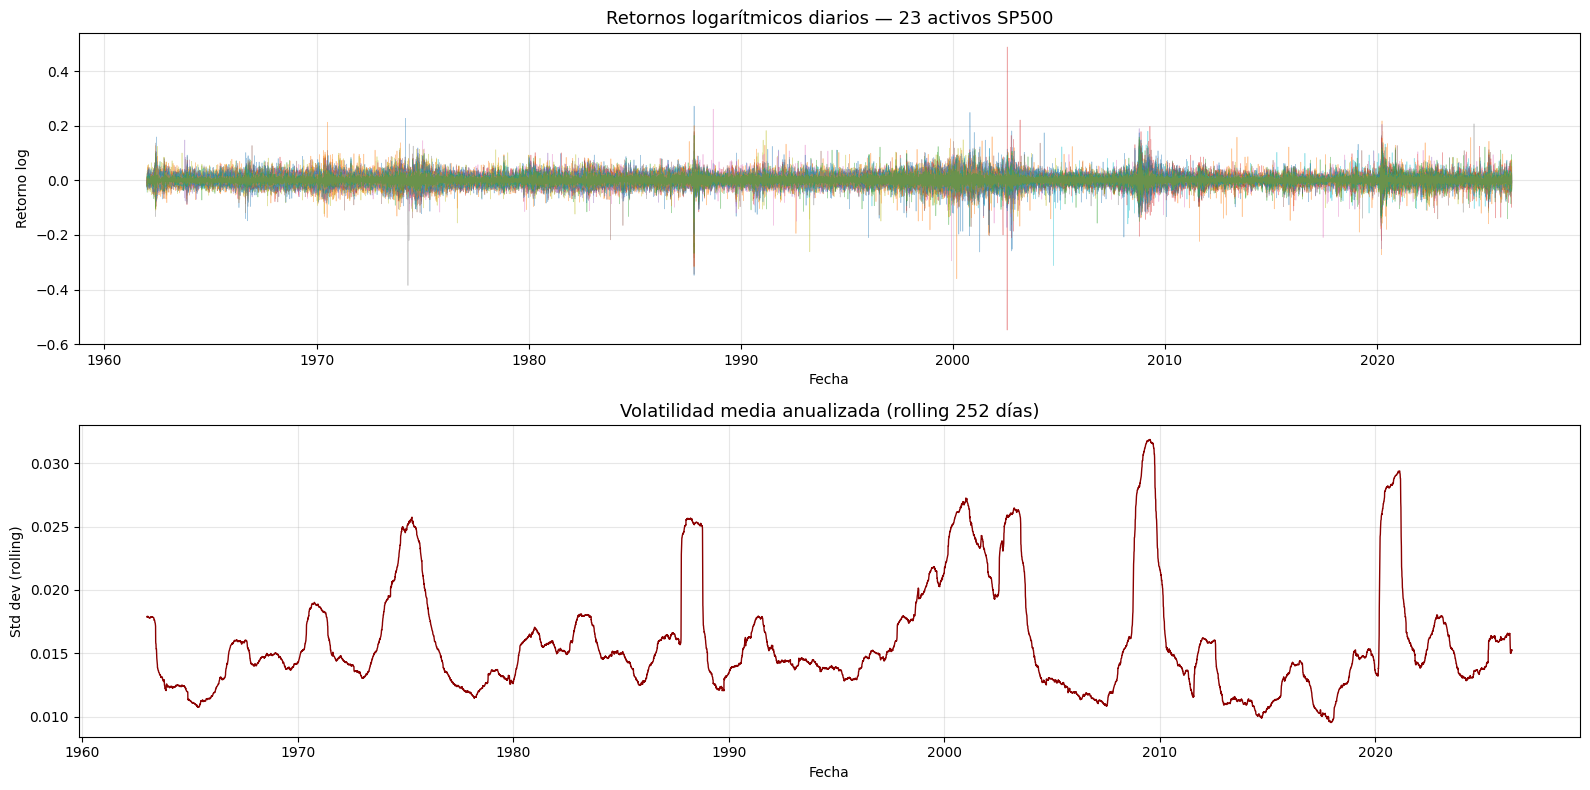

In [9]:
# Visualización exploratoria de los retornos
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(returns.index, returns.values, alpha=0.4, linewidth=0.5)
axes[0].set_title('Retornos logarítmicos diarios — 23 activos SP500', fontsize=13)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Retorno log')
axes[0].grid(True, alpha=0.3)

axes[1].plot(returns.index, returns.rolling(252).std().mean(axis=1), color='darkred', linewidth=1)
axes[1].set_title('Volatilidad media anualizada (rolling 252 días)', fontsize=13)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Std dev (rolling)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figuras/exploracion_datos.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Función de Creación de Series Temporales



In [10]:
def create_time_series_data(data, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): Número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): Número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y)
            X: shape (num_samples, input_window_size, num_features)
            y: shape (num_samples, num_features)  — promedio sobre la ventana de salida
    """
    X, y = [], []
    data_array = data.values if isinstance(data, pd.DataFrame) else data
    num_features = data_array.shape[1]

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        if output_window_size > 0:
            output_sequence = data_array[
                i + input_window_size : i + input_window_size + output_window_size
            ]
            average_output = np.mean(output_sequence, axis=0)
            y.append(average_output)
        else:
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

## 4. Modelos: Definiciones de Arquitecturas Densas

Se definen **7 arquitecturas densas** distintas más el baseline "Buy and Hold":

| ID | Nombre | Descripción |
|---|---|---|
| 0 | Buy & Hold | Baseline: predice la media de la ventana de entrada |
| 1 | MLP-Shallow | 1 capa oculta (128 unidades) |
| 2 | MLP-Medium | 2 capas (256 → 128) |
| 3 | MLP-Deep | 4 capas (512 → 256 → 128 → 64) |
| 4 | MLP-Dropout | 3 capas con Dropout(0.3) para regularización |
| 5 | MLP-BatchNorm | 3 capas con BatchNormalization |
| 6 | MLP-Wide | 2 capas muy anchas (1024 → 512) |
| 7 | MLP-Residual | Bloque residual denso (skip connections) |

In [11]:
def build_mlp_shallow(input_dim, output_dim):
    """MLP con 1 capa oculta de 128 unidades."""
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dense(output_dim)
    ], name='MLP_Shallow')
    model.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=1e-3))
    return model


def build_mlp_medium(input_dim, output_dim):
    """MLP con 2 capas ocultas: 256 → 128."""
    model = Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        Dense(128, activation='relu'),
        Dense(output_dim)
    ], name='MLP_Medium')
    model.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=1e-3))
    return model


def build_mlp_deep(input_dim, output_dim):
    """MLP profunda con 4 capas ocultas: 512 → 256 → 128 → 64."""
    model = Sequential([
        Dense(512, activation='relu', input_dim=input_dim),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(output_dim)
    ], name='MLP_Deep')
    model.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=5e-4))
    return model


def build_mlp_dropout(input_dim, output_dim):
    """MLP con Dropout(0.3) para regularización."""
    model = Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(output_dim)
    ], name='MLP_Dropout')
    model.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=1e-3))
    return model


def build_mlp_batchnorm(input_dim, output_dim):
    """MLP con BatchNormalization tras cada capa."""
    model = Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dense(output_dim)
    ], name='MLP_BatchNorm')
    model.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=1e-3))
    return model


def build_mlp_wide(input_dim, output_dim):
    """MLP ancha con 2 capas de gran anchura: 1024 → 512."""
    model = Sequential([
        Dense(1024, activation='relu', input_dim=input_dim),
        Dense(512, activation='relu'),
        Dense(output_dim)
    ], name='MLP_Wide')
    model.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=5e-4))
    return model


def build_mlp_residual(input_dim, output_dim):
    """
    MLP con bloques residuales (skip connections).
    La conexión residual suma la entrada del bloque a su salida,
    facilitando el flujo del gradiente en redes profundas.
    """
    inputs = Input(shape=(input_dim,), name='input')

    # Proyección de dimensión para compatibilidad
    proj = Dense(256, activation='linear', name='projection')(inputs)

    # Bloque residual 1
    x = Dense(256, activation='relu', name='res1_fc1')(proj)
    x = Dense(256, activation='linear', name='res1_fc2')(x)
    x = Add(name='res1_add')([x, proj])
    x = Activation('relu', name='res1_relu')(x)

    # Bloque residual 2
    y = Dense(256, activation='relu', name='res2_fc1')(x)
    y = Dense(256, activation='linear', name='res2_fc2')(y)
    y = Add(name='res2_add')([y, x])
    y = Activation('relu', name='res2_relu')(y)

    # Capa de salida
    outputs = Dense(output_dim, name='output')(y)

    model = Model(inputs=inputs, outputs=outputs, name='MLP_Residual')
    model.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=5e-4))
    return model


# Diccionario de constructores
MODEL_BUILDERS = {
    'MLP-Shallow':   build_mlp_shallow,
    'MLP-Medium':    build_mlp_medium,
    'MLP-Deep':      build_mlp_deep,
    'MLP-Dropout':   build_mlp_dropout,
    'MLP-BatchNorm': build_mlp_batchnorm,
    'MLP-Wide':      build_mlp_wide,
    'MLP-Residual':  build_mlp_residual,
}

print(f'Arquitecturas densas definidas: {list(MODEL_BUILDERS.keys())}')
print(f'+ Baseline: Buy & Hold')

Arquitecturas densas definidas: ['MLP-Shallow', 'MLP-Medium', 'MLP-Deep', 'MLP-Dropout', 'MLP-BatchNorm', 'MLP-Wide', 'MLP-Residual']
+ Baseline: Buy & Hold


## 5. Baseline: Buy and Hold

El modelo **Buy and Hold** predice que el retorno promedio futuro será igual al retorno promedio de la ventana de entrada. Es el benchmark más sencillo y razonable para este problema.

In [12]:
def buy_and_hold_predict(X):
    """
    Predicción Buy & Hold: promedio de los retornos en la ventana de entrada.
    X tiene shape (N, input_window, 23).
    Devuelve shape (N, 23).
    """
    return np.mean(X, axis=1)  # Media sobre la dimensión temporal


def mae_score(y_true, y_pred):
    """Calcula el MAE medio entre todos los activos."""
    return float(np.mean(np.abs(y_true - y_pred)))


print('Funciones auxiliares definidas correctamente.')

Funciones auxiliares definidas correctamente.


## 6. Bucle Principal: Entrenamiento sobre las 16 Combinaciones de Ventanas

Para cada una de las 16 combinaciones (input_window × output_window) se:
1. Construyen los datos X e y con `create_time_series_data`
2. Divide en train/val/test (90/4.5/10 %)
3. Aplana X para las capas densas
4. Entrena cada modelo con EarlyStopping
5. Registra MAE en train, val y test
6. Guarda curva de convergencia

In [13]:
# Configuración de ventanas
INPUT_WINDOWS  = [5, 10, 30, 90]
OUTPUT_WINDOWS = [1, 5, 30, 90]

# Hiperparámetros de entrenamiento
MAX_EPOCHS = 150
PATIENCE   = 15       # EarlyStopping patience
BATCH_SIZE = 256

# Almacenamiento de resultados
results_list = []        # Lista de dicts con todos los resultados
histories    = {}        # Historial de entrenamiento por (in_w, out_w, model_name)
best_models  = {}        # Mejor modelo por combinación

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=0
    )
]

total_combos = len(INPUT_WINDOWS) * len(OUTPUT_WINDOWS)
combo_idx = 0

for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        combo_idx += 1
        print(f'\n{'='*65}')
        print(f'  COMBINACIÓN {combo_idx}/{total_combos}:  '
              f'Ventana entrada={in_w}d  |  Ventana salida={out_w}d')
        print(f'{'='*65}')

        # ── 1. Datos ──────────────────────────────────────────────────
        X, y = create_time_series_data(returns, in_w, out_w)

        # Train/Test split (90/10, sin shuffle)
        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X, y, test_size=0.1, shuffle=False, random_state=RANDOM_SEED
        )

        # Validación del 5% del train
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full,
            test_size=0.05, shuffle=False, random_state=RANDOM_SEED
        )

        # Flatten para capas densas: (N, in_w, 23) → (N, in_w*23)
        X_train_flat = X_train.reshape(len(X_train), -1)
        X_val_flat   = X_val.reshape(len(X_val), -1)
        X_test_flat  = X_test.reshape(len(X_test), -1)

        input_dim  = X_train_flat.shape[1]   # in_w * 23
        output_dim = y_train.shape[1]         # 23

        print(f'  Datos — Train: {X_train_flat.shape} | '
              f'Val: {X_val_flat.shape} | Test: {X_test_flat.shape}')

        # ── 2. Baseline: Buy & Hold ────────────────────────────────────
        bh_train = buy_and_hold_predict(X_train)
        bh_val   = buy_and_hold_predict(X_val)
        bh_test  = buy_and_hold_predict(X_test)

        results_list.append({
            'in_window':   in_w,
            'out_window':  out_w,
            'model':       'Buy & Hold',
            'params':      0,
            'mae_train':   mae_score(y_train, bh_train),
            'mae_val':     mae_score(y_val,   bh_val),
            'mae_test':    mae_score(y_test,  bh_test),
            'epochs_run':  0,
        })
        print(f'  [Buy & Hold]  '
              f'MAE test = {mae_score(y_test, bh_test):.6f}')

        # ── 3. Modelos densos ──────────────────────────────────────────
        combo_key = (in_w, out_w)
        best_test_mae = np.inf
        best_model_name = None

        for model_name, builder in MODEL_BUILDERS.items():
            tf.random.set_seed(RANDOM_SEED)
            np.random.seed(RANDOM_SEED)

            model = builder(input_dim, output_dim)
            n_params = model.count_params()

            hist = model.fit(
                X_train_flat, y_train,
                validation_data=(X_val_flat, y_val),
                epochs=MAX_EPOCHS,
                batch_size=BATCH_SIZE,
                callbacks=callbacks,
                verbose=0
            )

            # Guardar historial
            histories[(in_w, out_w, model_name)] = hist.history

            # Predicciones
            y_pred_tr  = model.predict(X_train_flat, verbose=0)
            y_pred_val = model.predict(X_val_flat,   verbose=0)
            y_pred_ts  = model.predict(X_test_flat,  verbose=0)

            mae_tr  = mae_score(y_train, y_pred_tr)
            mae_val = mae_score(y_val,   y_pred_val)
            mae_ts  = mae_score(y_test,  y_pred_ts)
            epochs_run = len(hist.history['loss'])

            results_list.append({
                'in_window':  in_w,
                'out_window': out_w,
                'model':      model_name,
                'params':     n_params,
                'mae_train':  mae_tr,
                'mae_val':    mae_val,
                'mae_test':   mae_ts,
                'epochs_run': epochs_run,
            })

            print(f'  [{model_name:<15}]  '
                  f'MAE tr={mae_tr:.6f}  val={mae_val:.6f}  '
                  f'test={mae_ts:.6f}  '
                  f'params={n_params:>8,}  epochs={epochs_run}')

            if mae_ts < best_test_mae:
                best_test_mae  = mae_ts
                best_model_name = model_name

            keras.backend.clear_session()

        best_models[combo_key] = (best_model_name, best_test_mae)
        print(f'  ★ Mejor modelo en test: {best_model_name} (MAE={best_test_mae:.6f})')

print('\n✓ Entrenamiento completado para las 16 combinaciones.')


  COMBINACIÓN 1/16:  Ventana entrada=5d  |  Ventana salida=1d
  Datos — Train: (13841, 115) | Val: (729, 115) | Test: (1619, 115)
  [Buy & Hold]  MAE test = 0.013628
  [MLP-Shallow    ]  MAE tr=0.011548  val=0.009233  test=0.012380  params=  17,815  epochs=22

  [MLP-Medium     ]  MAE tr=0.011604  val=0.009217  test=0.012314  params=  65,559  epochs=19
  [MLP-Deep       ]  MAE tr=0.011515  val=0.009198  test=0.012347  params= 233,367  epochs=24
  [MLP-Dropout    ]  MAE tr=0.011686  val=0.009222  test=0.012284  params= 131,351  epochs=15
  [MLP-BatchNorm  ]  MAE tr=0.030247  val=0.029297  test=0.030715  params= 133,911  epochs=15
  [MLP-Wide       ]  MAE tr=0.011636  val=0.009229  test=0.012315  params= 655,383  epochs=15
  [MLP-Residual   ]  MAE tr=0.011719  val=0.009254  test=0.012363  params= 298,775  epochs=15
  ★ Mejor modelo en test: MLP-Dropout (MAE=0.012284)

  COMBINACIÓN 2/16:  Ventana entrada=5d  |  Ventana salida=5d
  Datos — Train: (13837, 115) | Val: (729, 115) | Test: (1

## 7. Curvas de Convergencia

Para cada modelo entrenado se muestra la curva de pérdida en train y validación, verificando que el entrenamiento ha convergido (sin overfitting severo gracias al EarlyStopping).

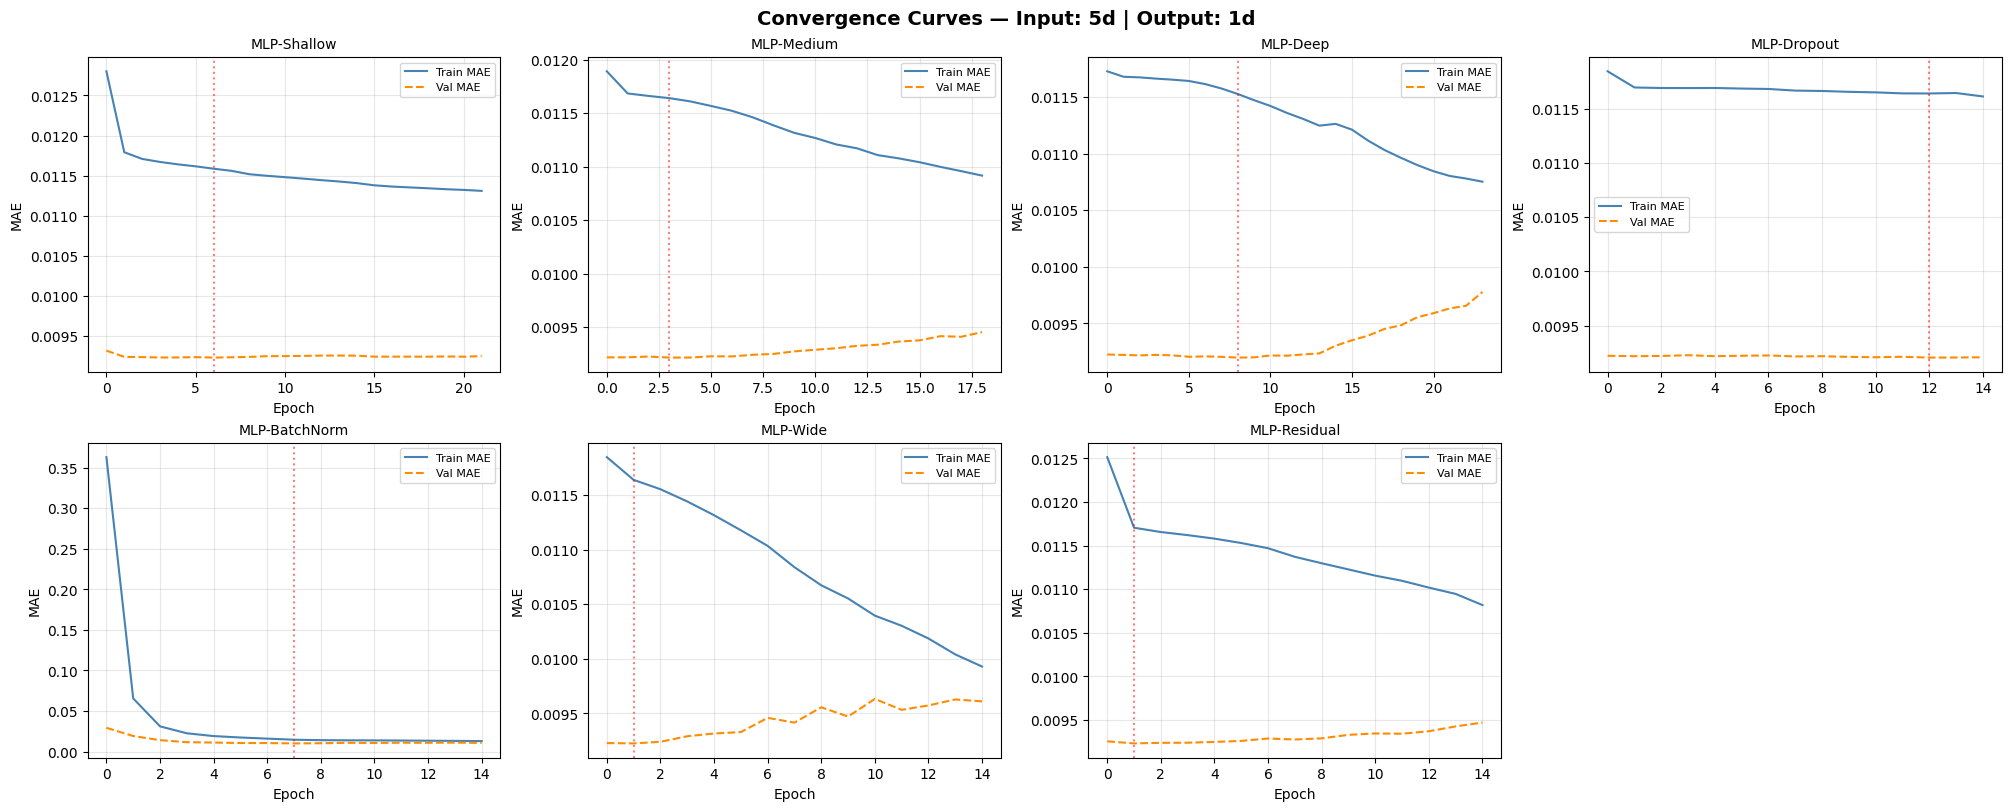

  → Saved: figuras/convergencia/conv_in5_out1.png


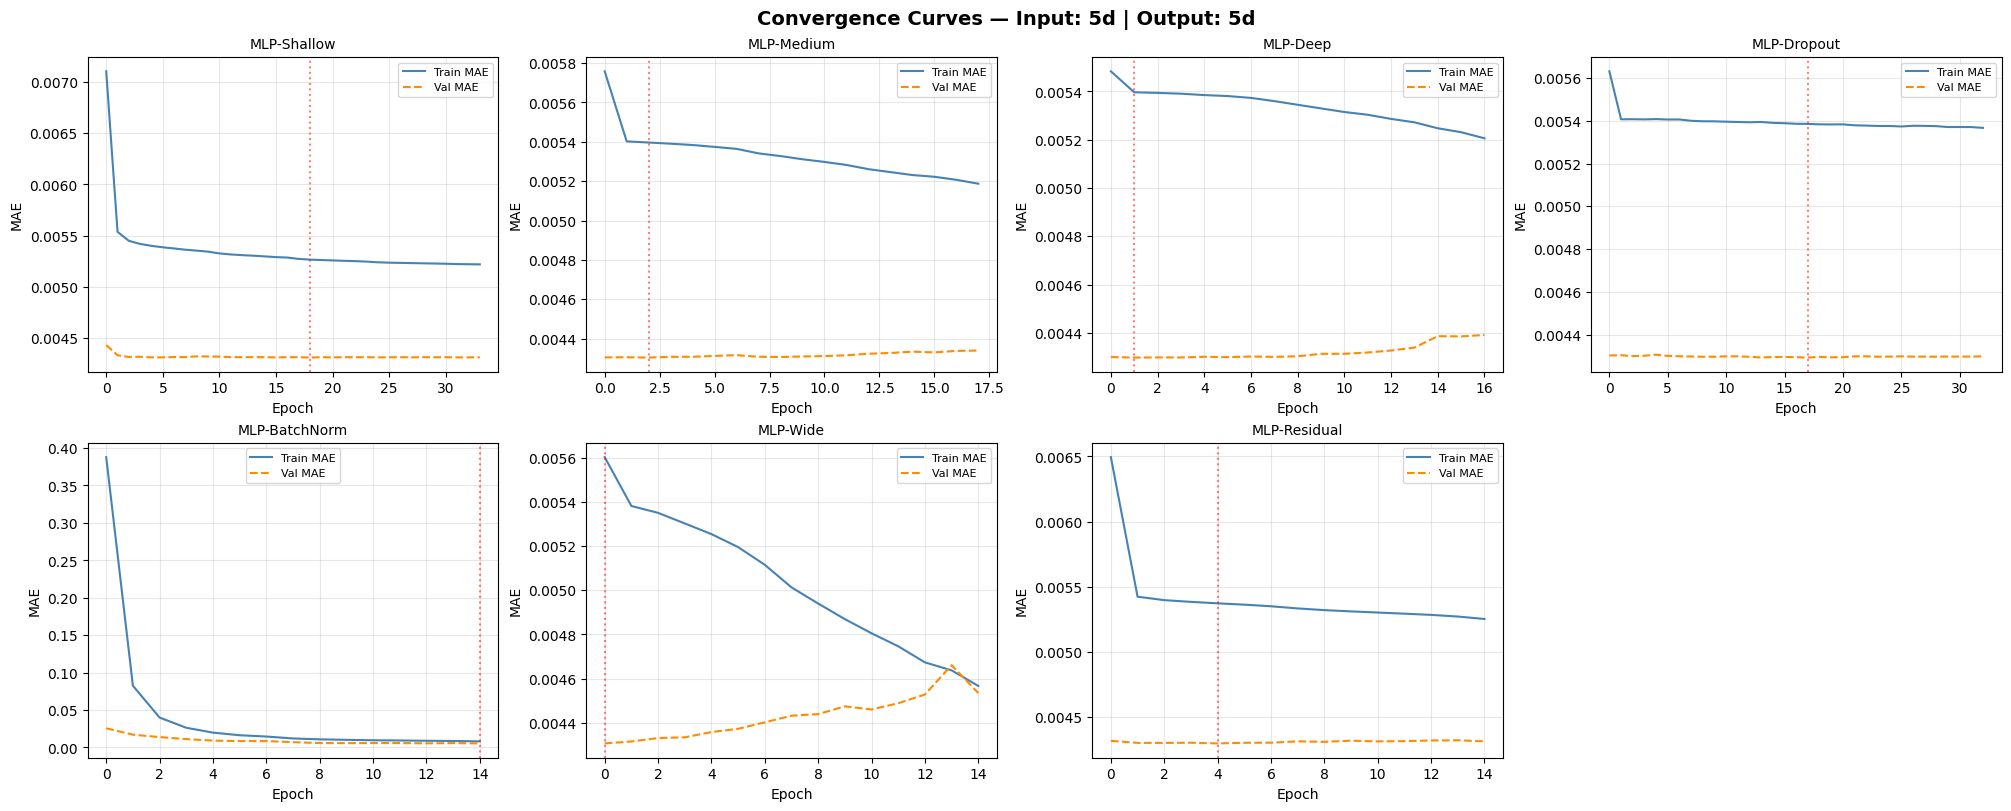

  → Saved: figuras/convergencia/conv_in5_out5.png


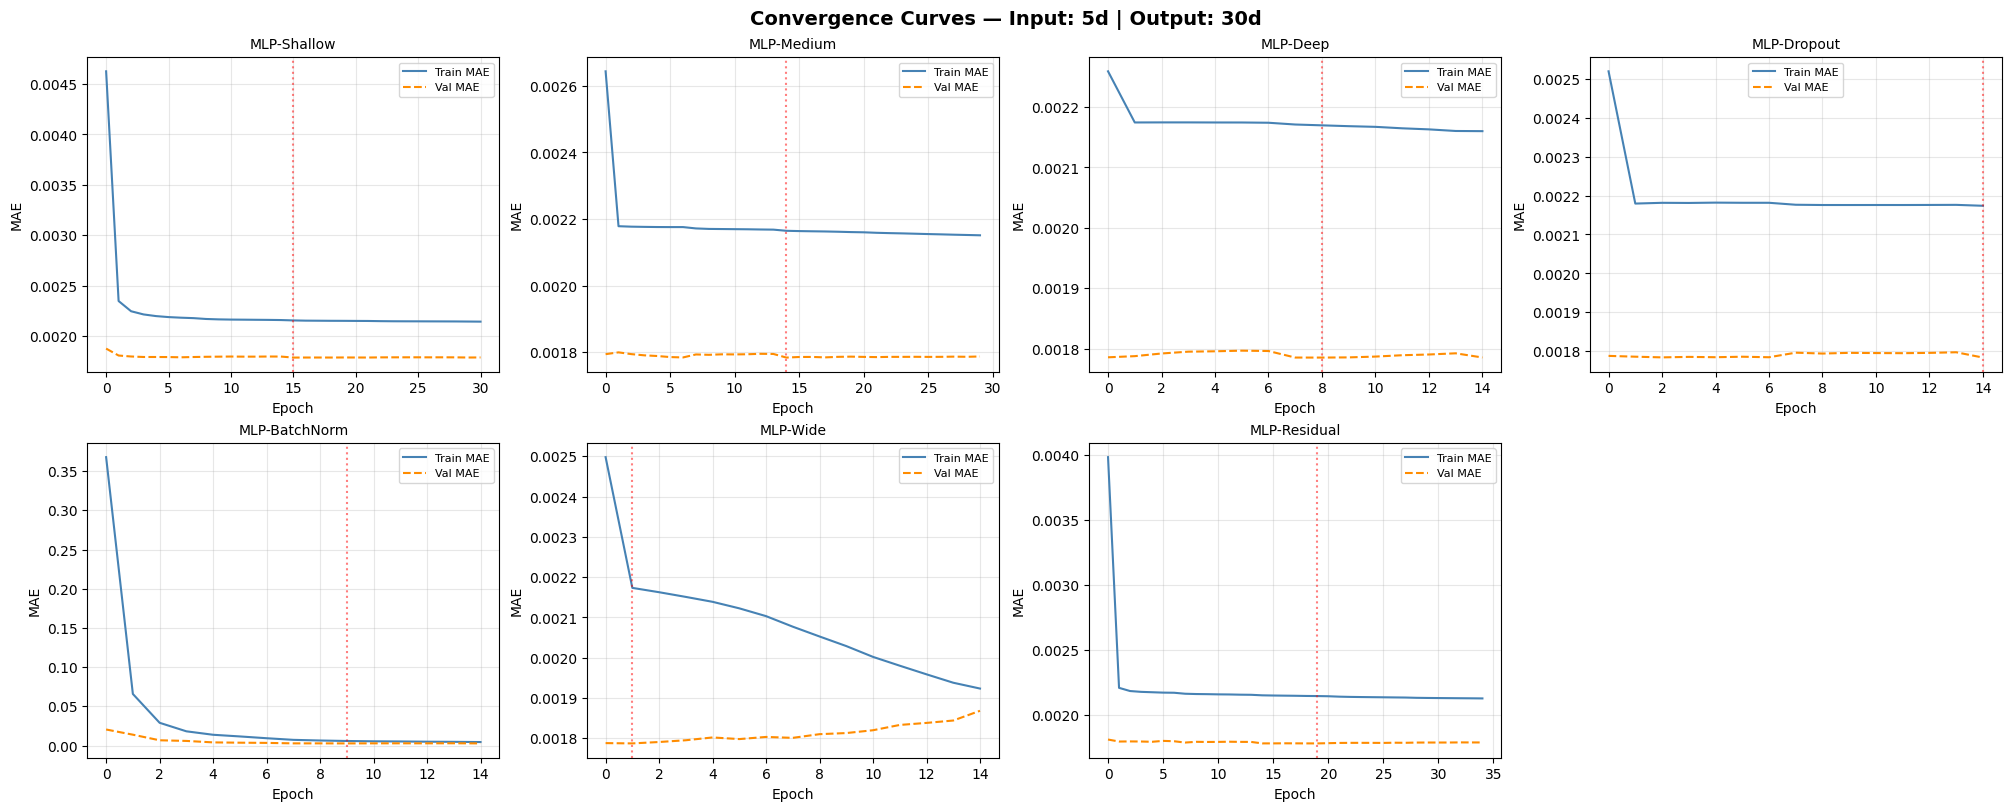

  → Saved: figuras/convergencia/conv_in5_out30.png


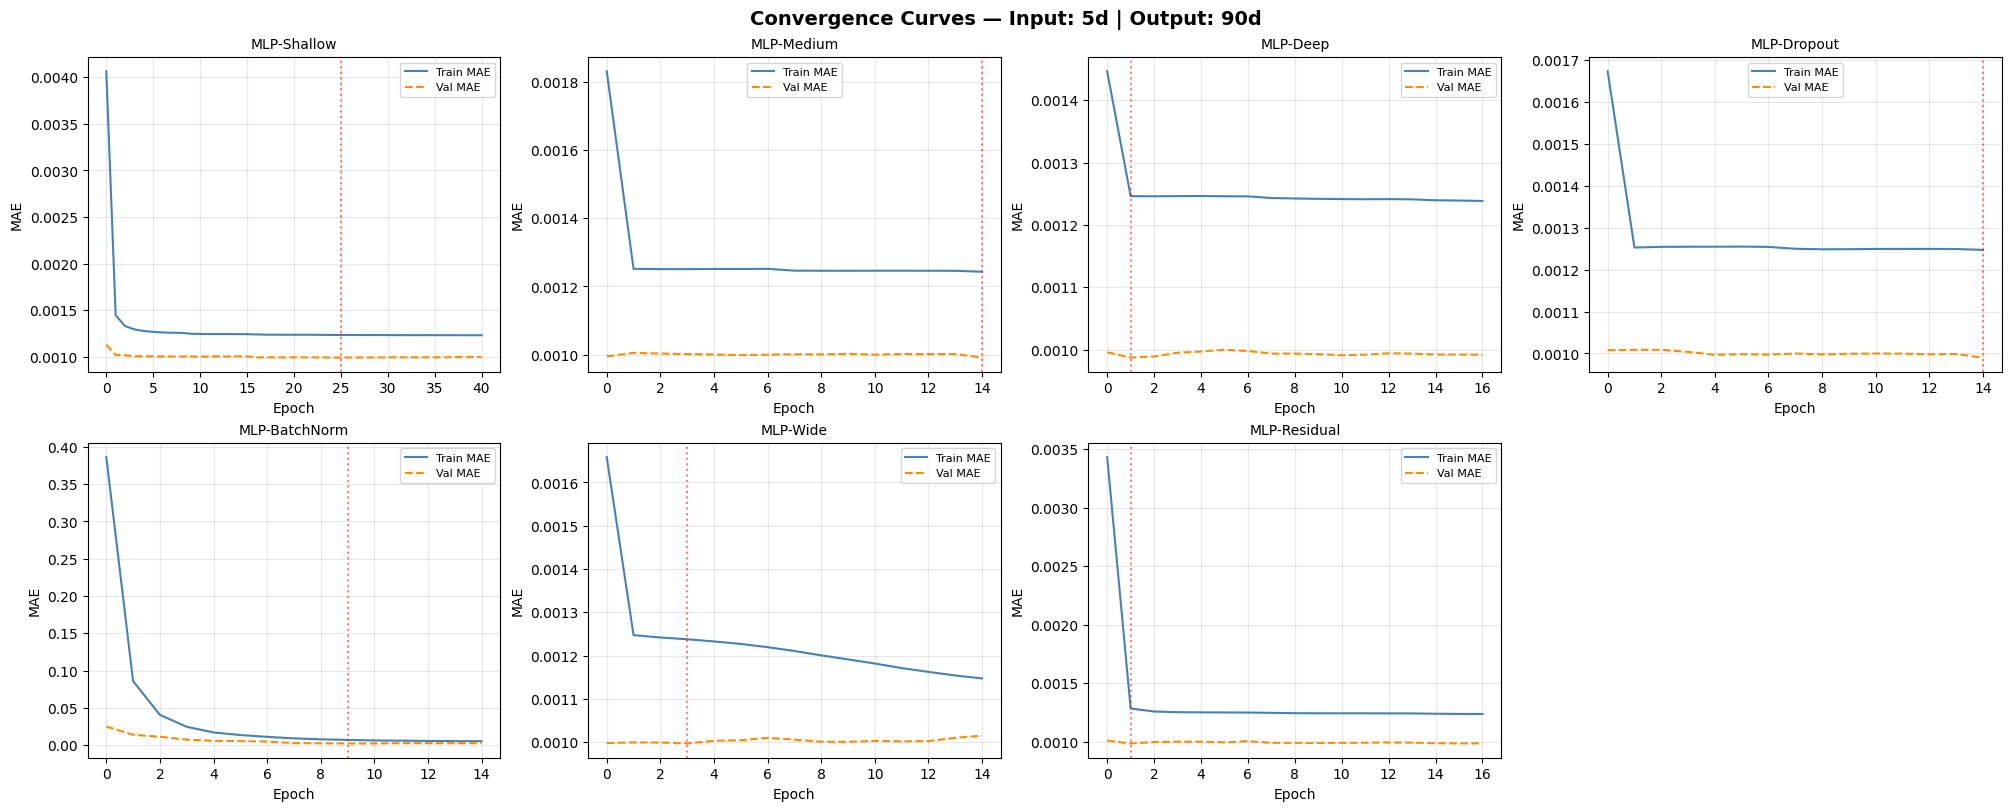

  → Saved: figuras/convergencia/conv_in5_out90.png


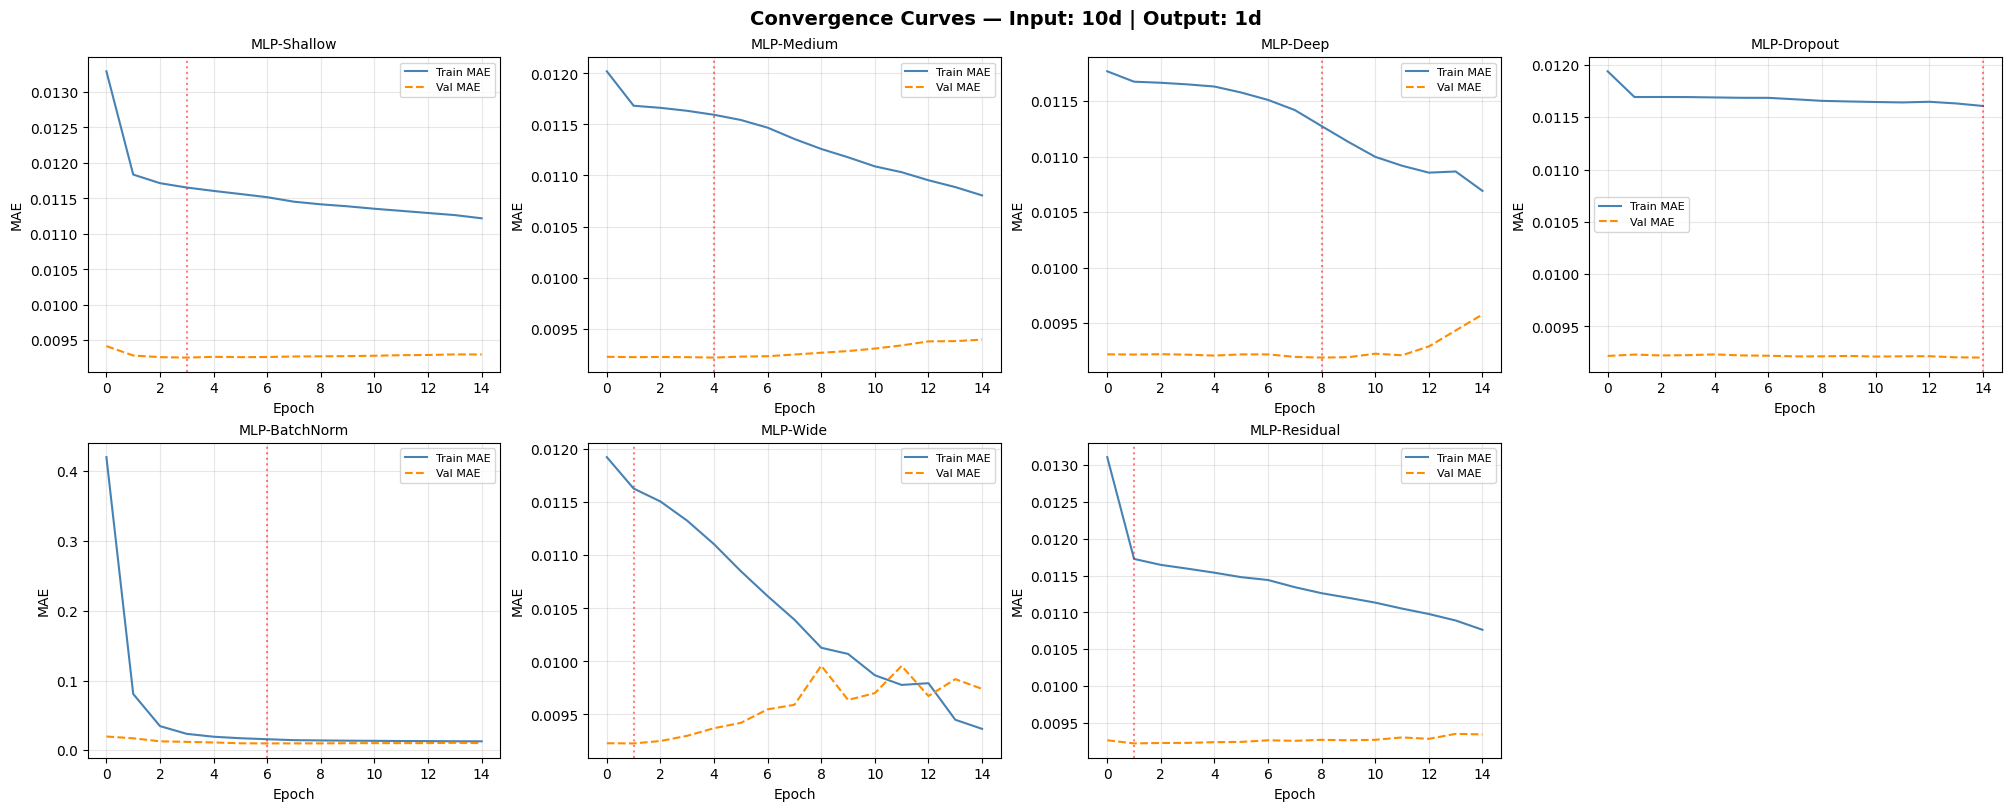

  → Saved: figuras/convergencia/conv_in10_out1.png


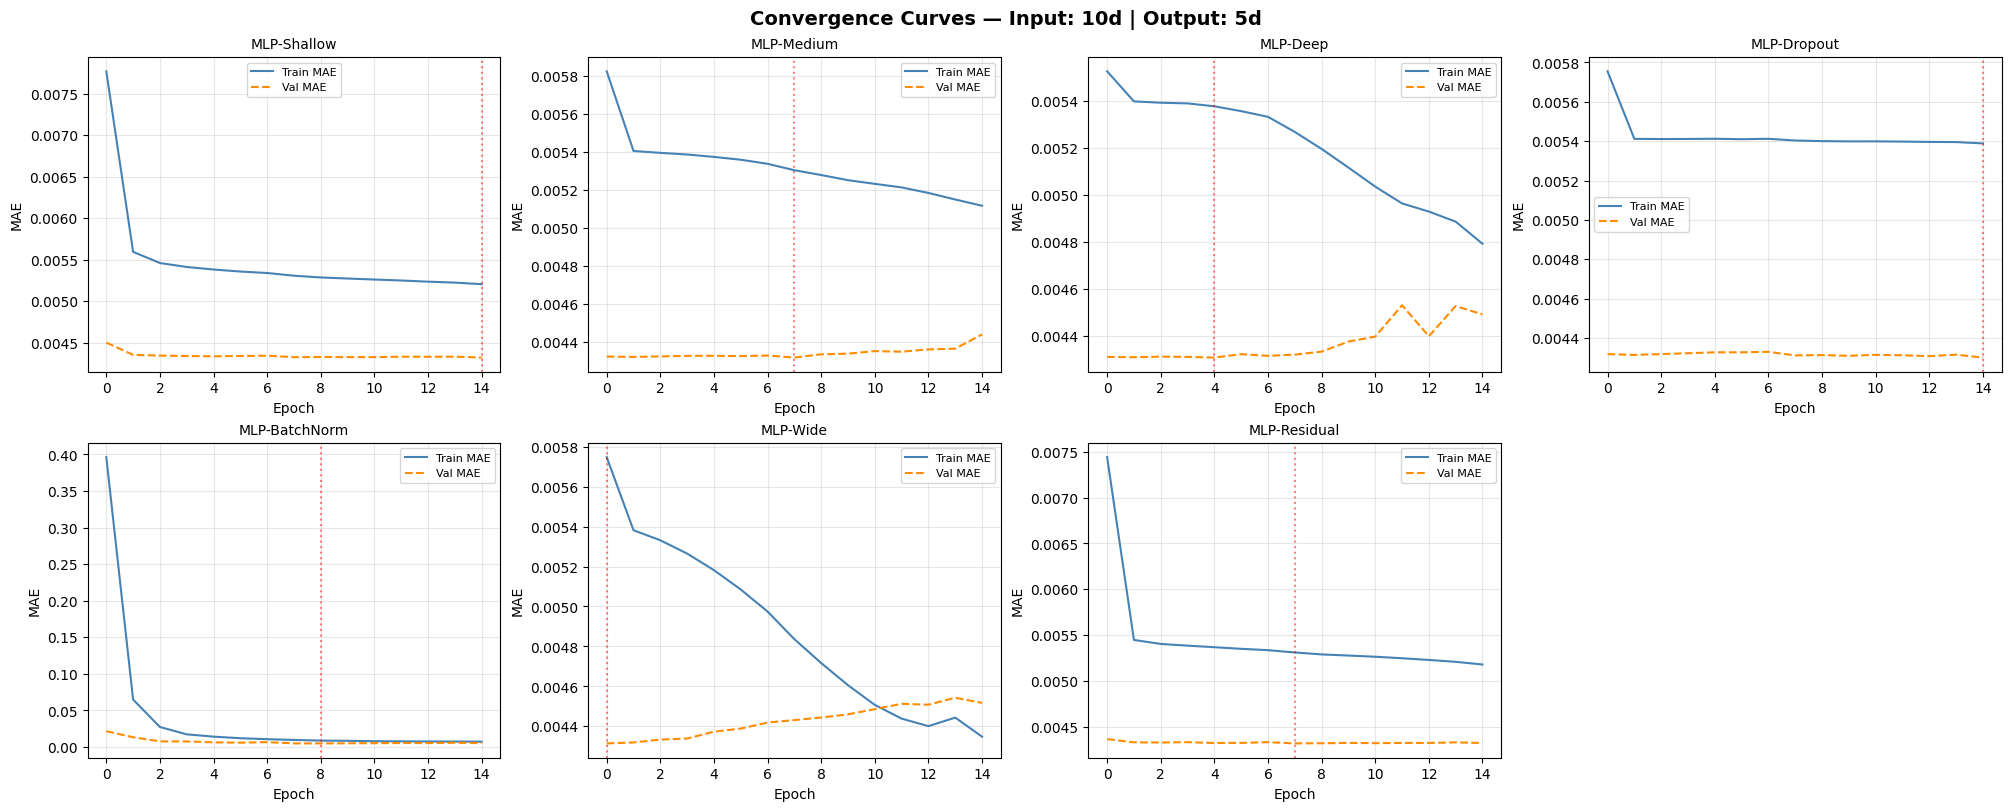

  → Saved: figuras/convergencia/conv_in10_out5.png


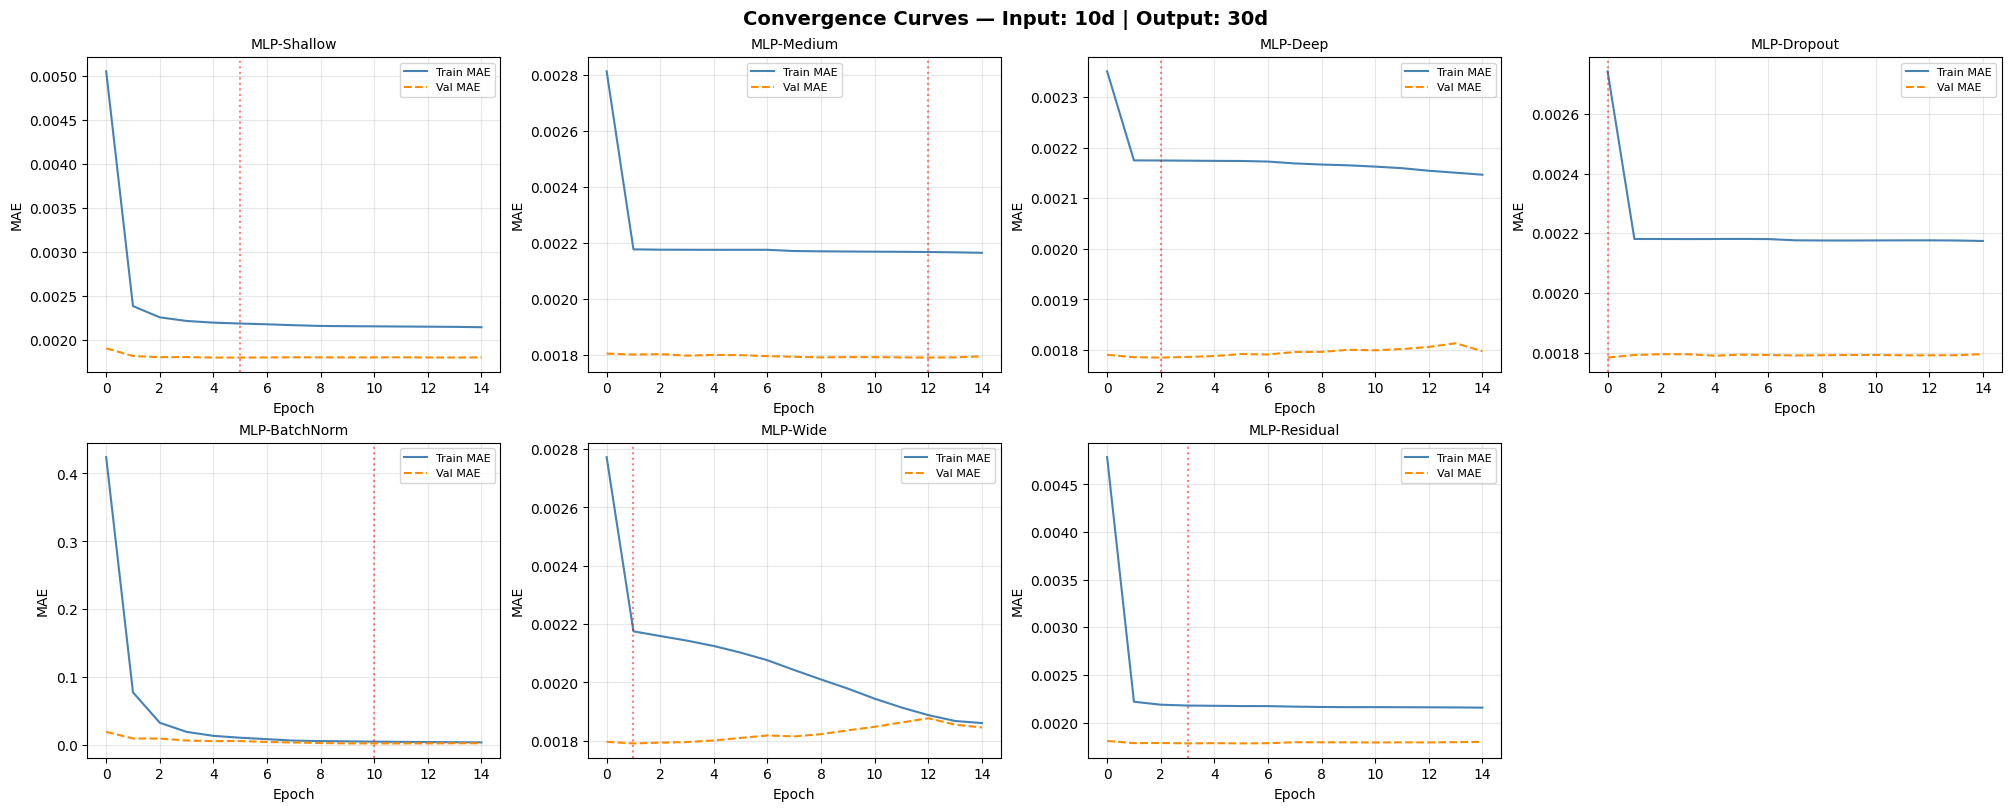

  → Saved: figuras/convergencia/conv_in10_out30.png


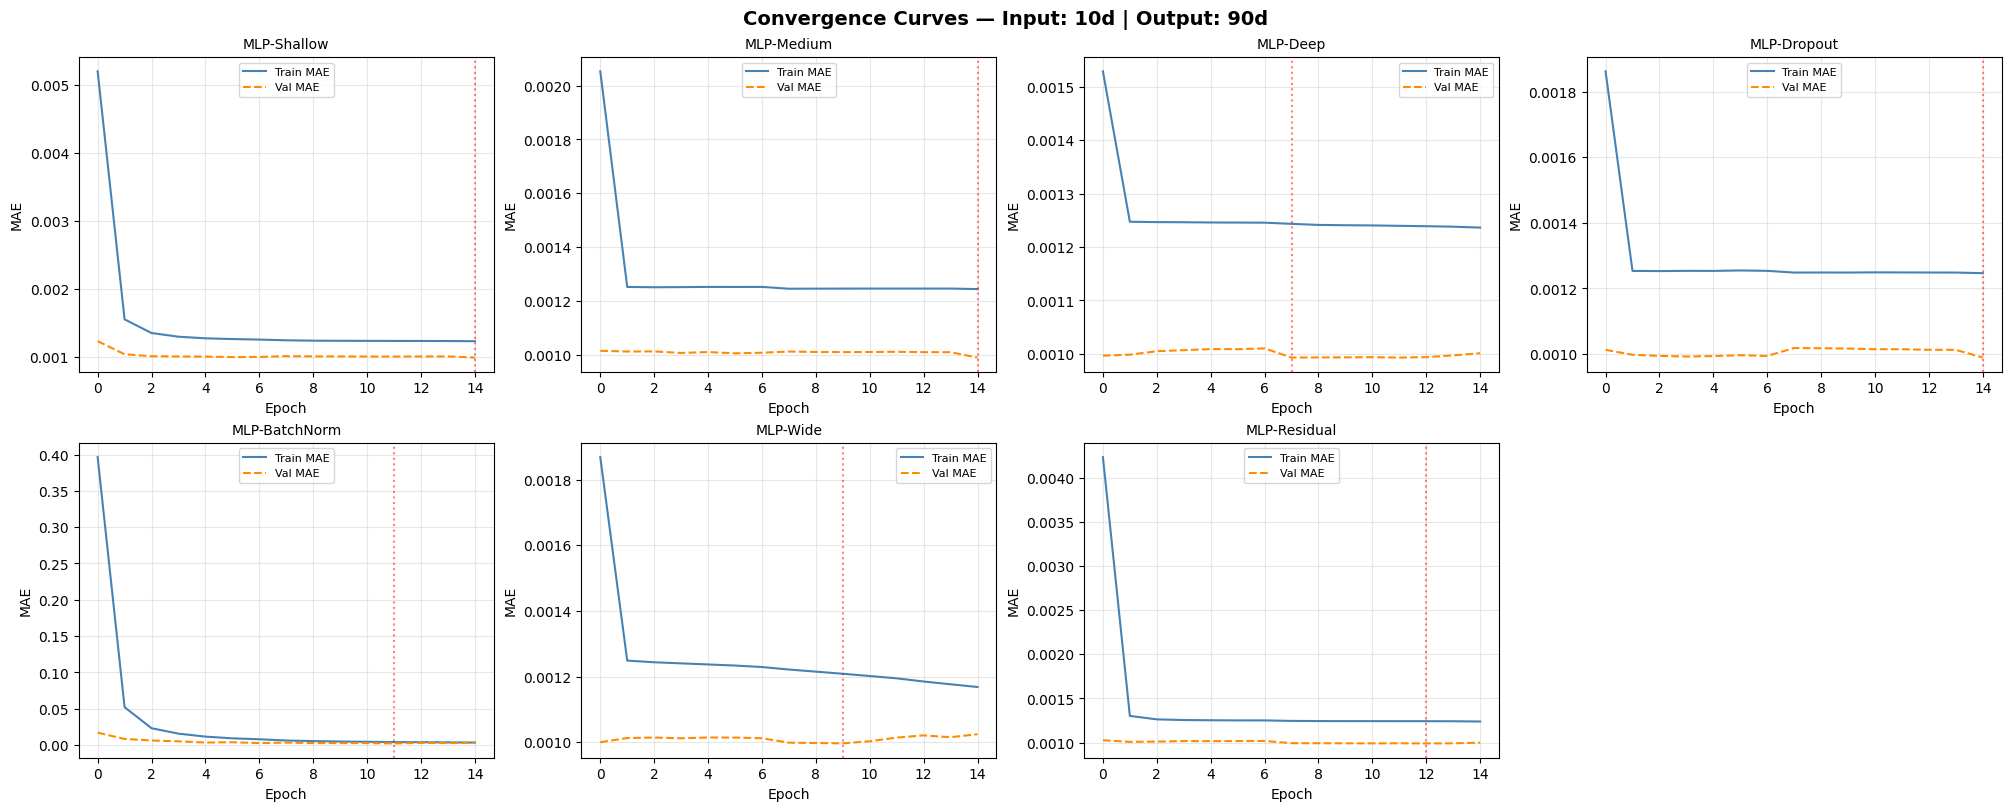

  → Saved: figuras/convergencia/conv_in10_out90.png


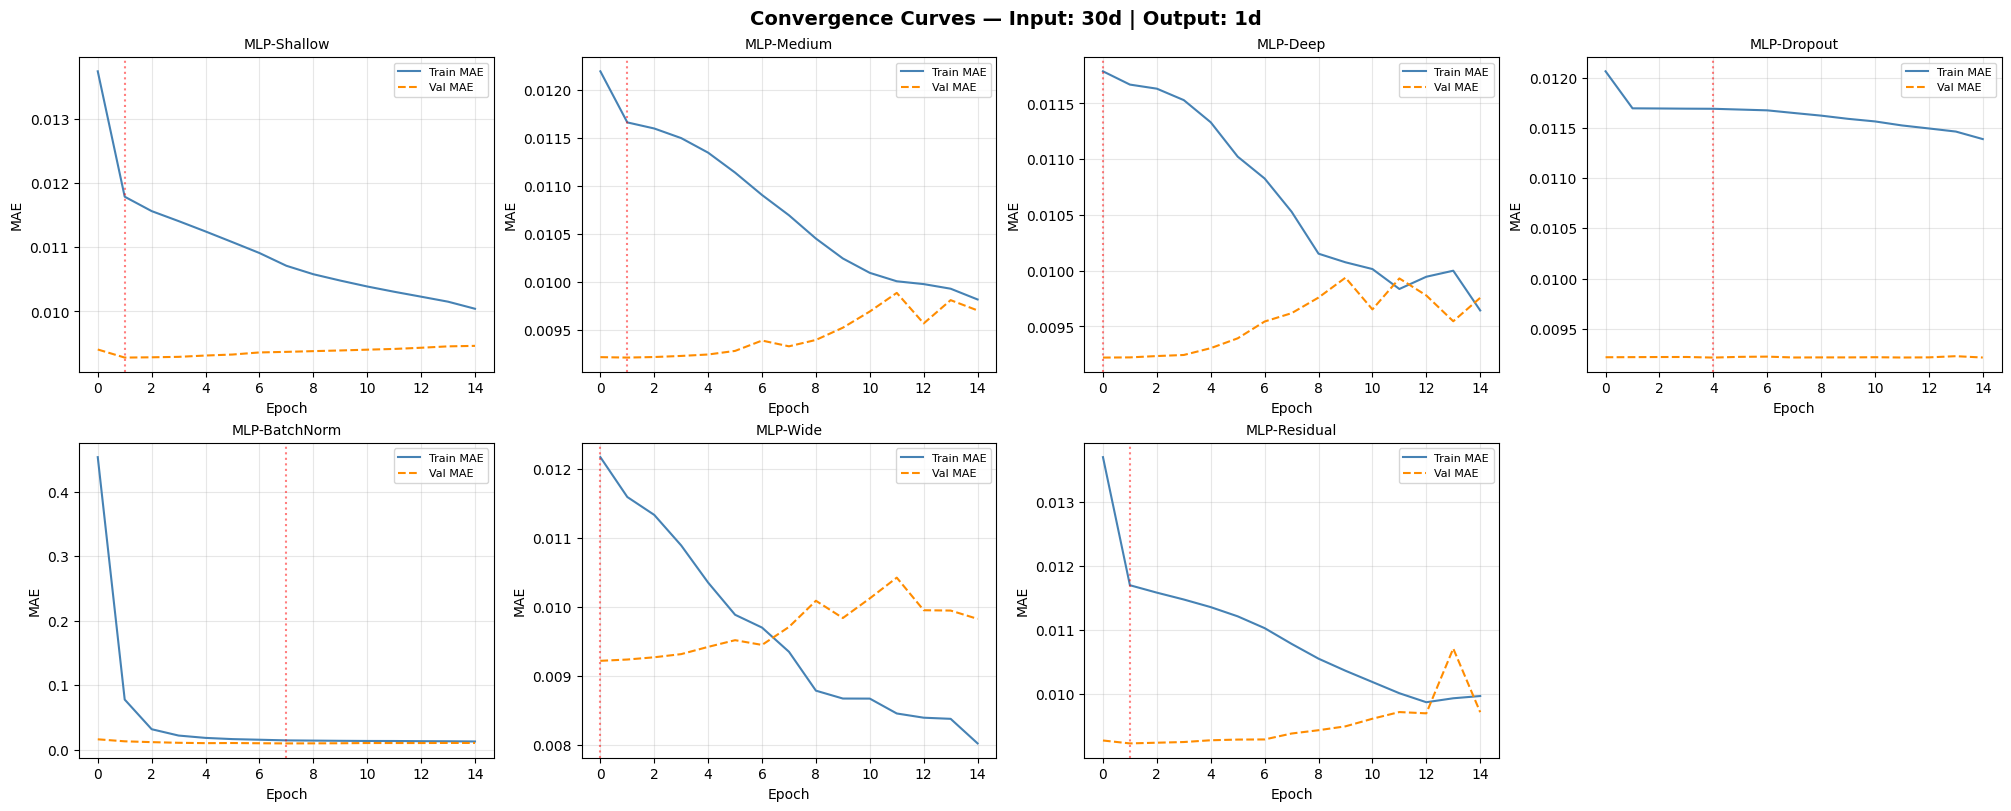

  → Saved: figuras/convergencia/conv_in30_out1.png


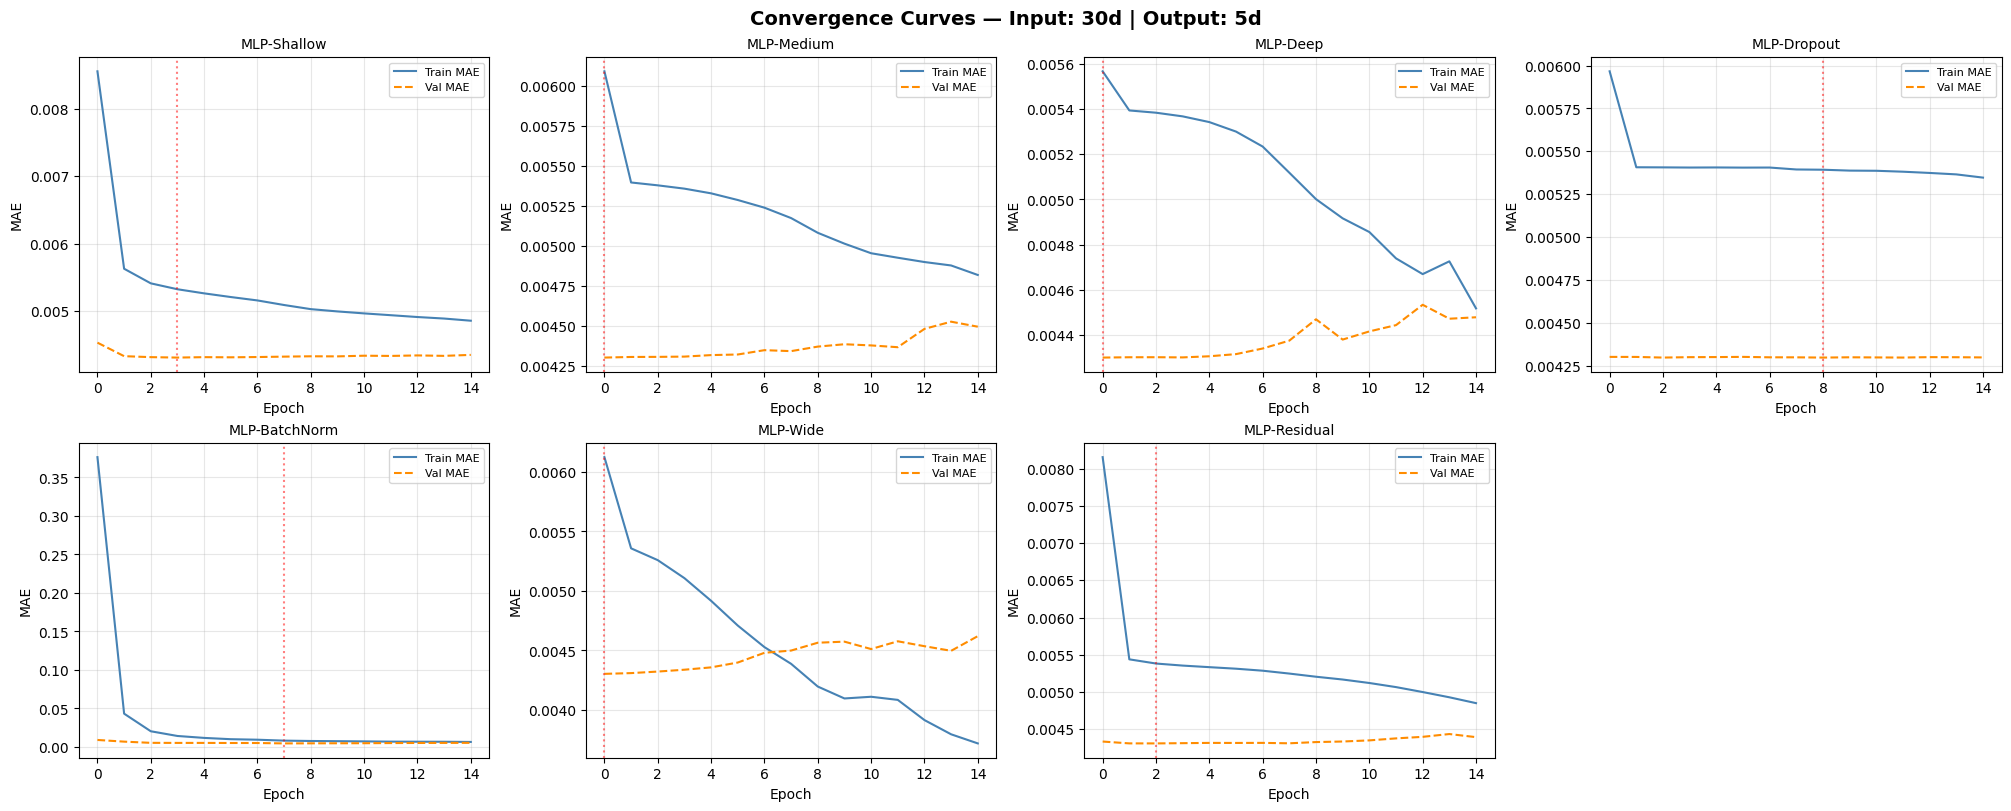

  → Saved: figuras/convergencia/conv_in30_out5.png


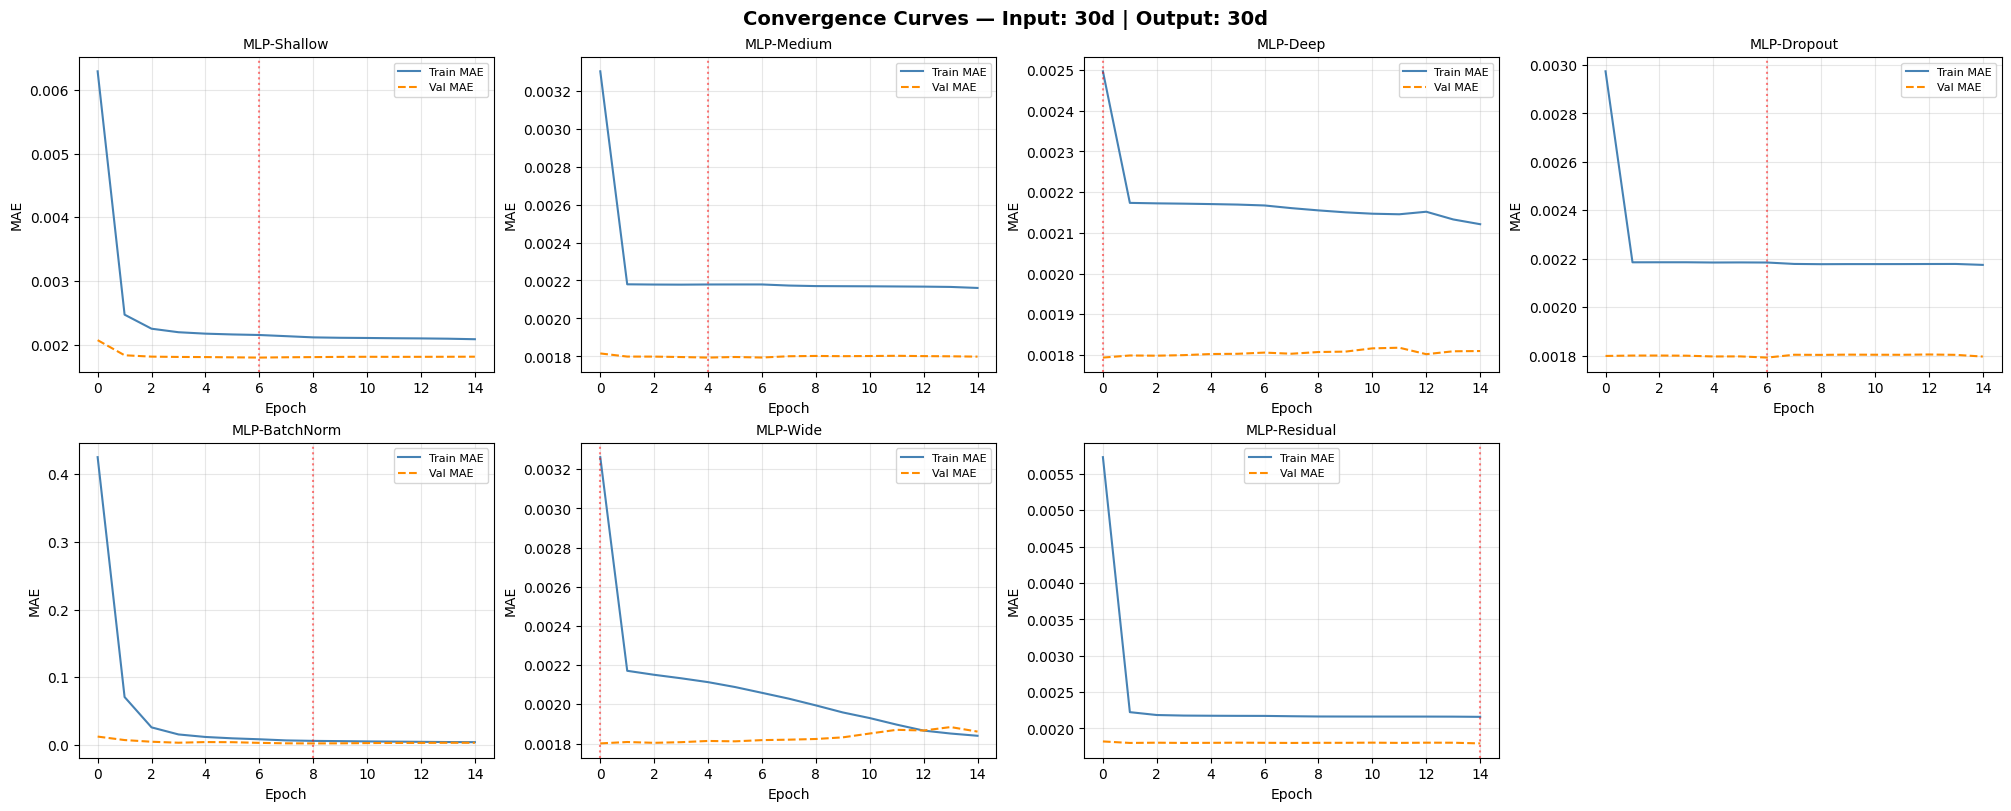

  → Saved: figuras/convergencia/conv_in30_out30.png


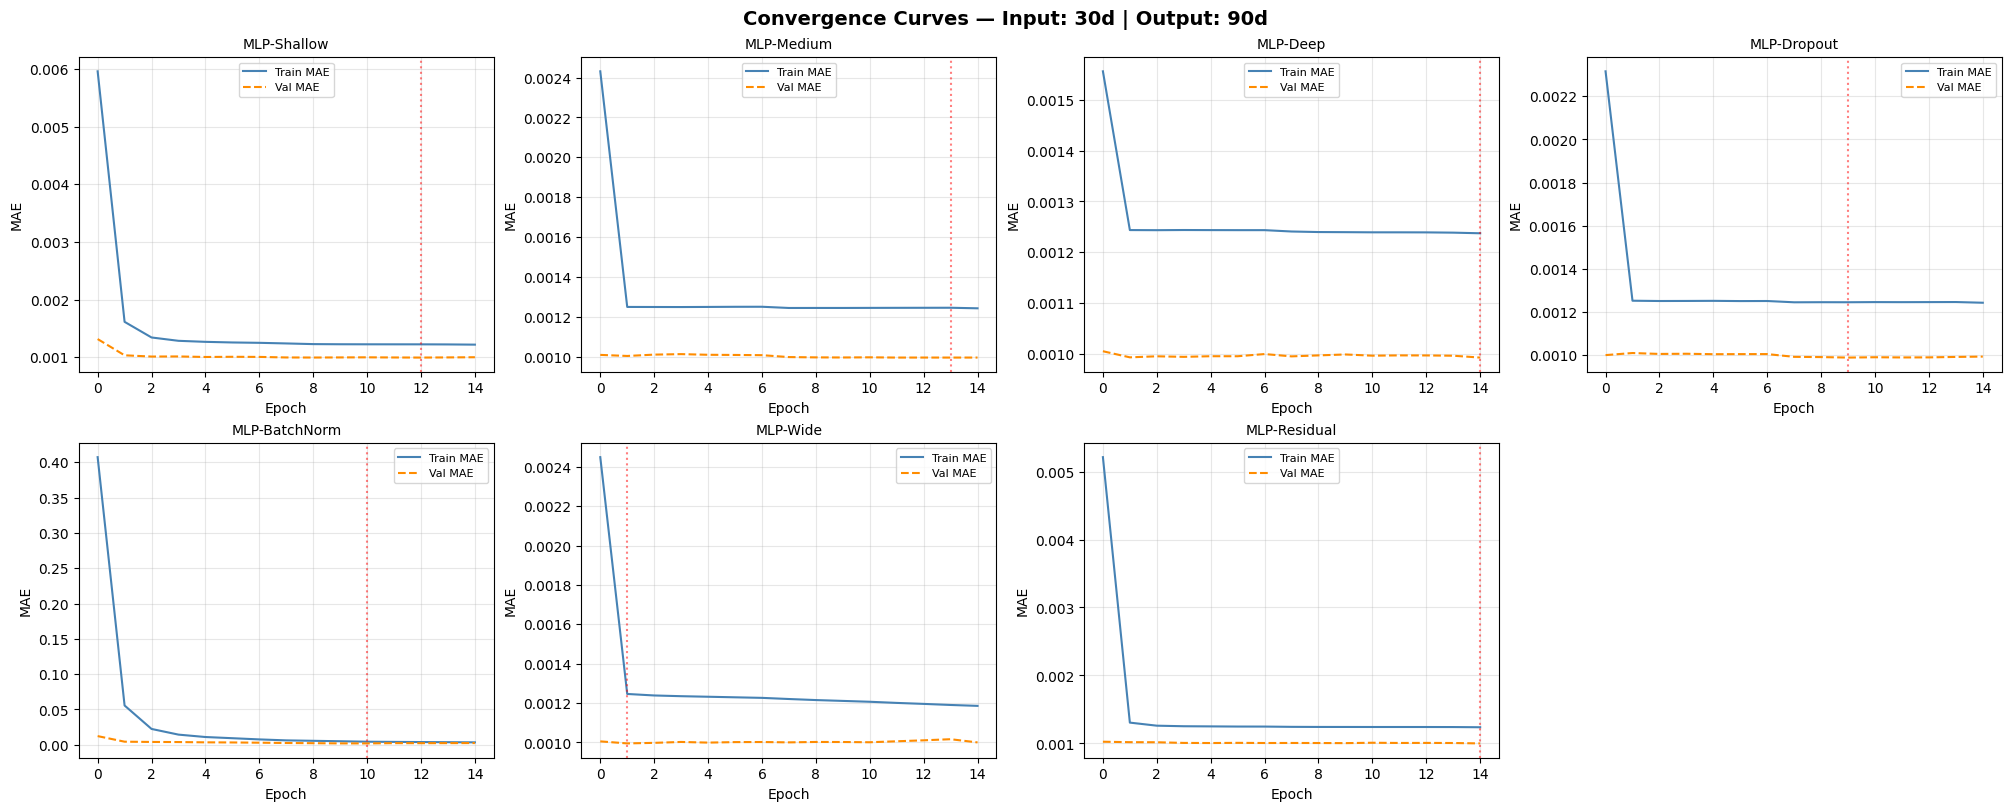

  → Saved: figuras/convergencia/conv_in30_out90.png


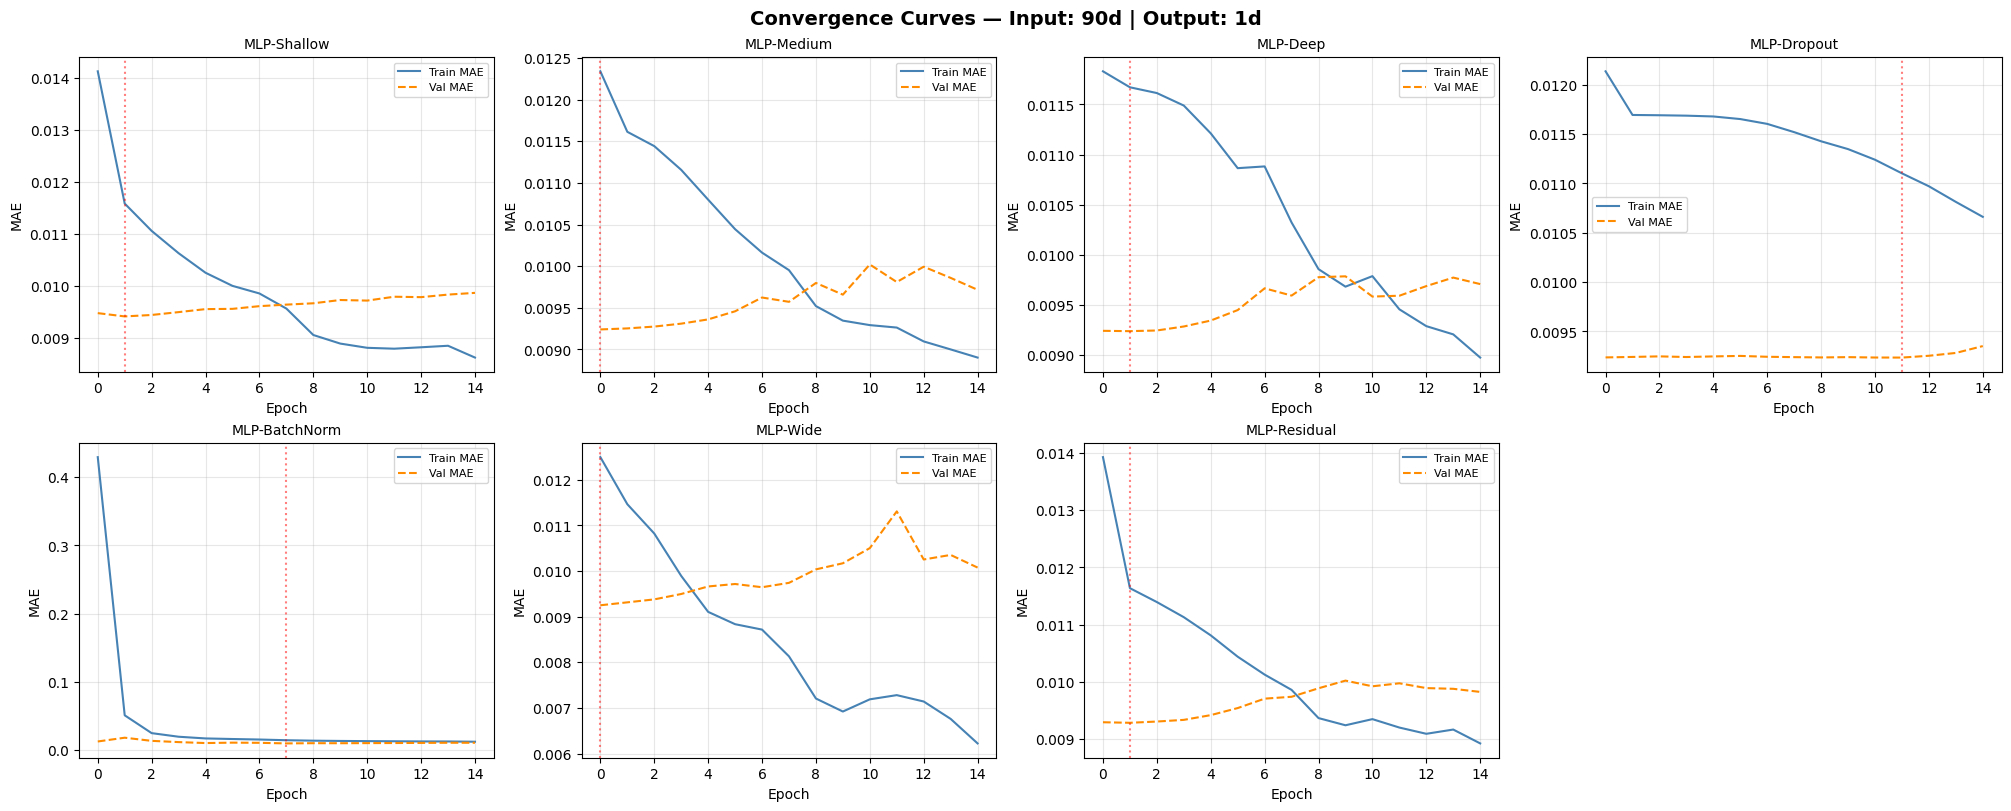

  → Saved: figuras/convergencia/conv_in90_out1.png


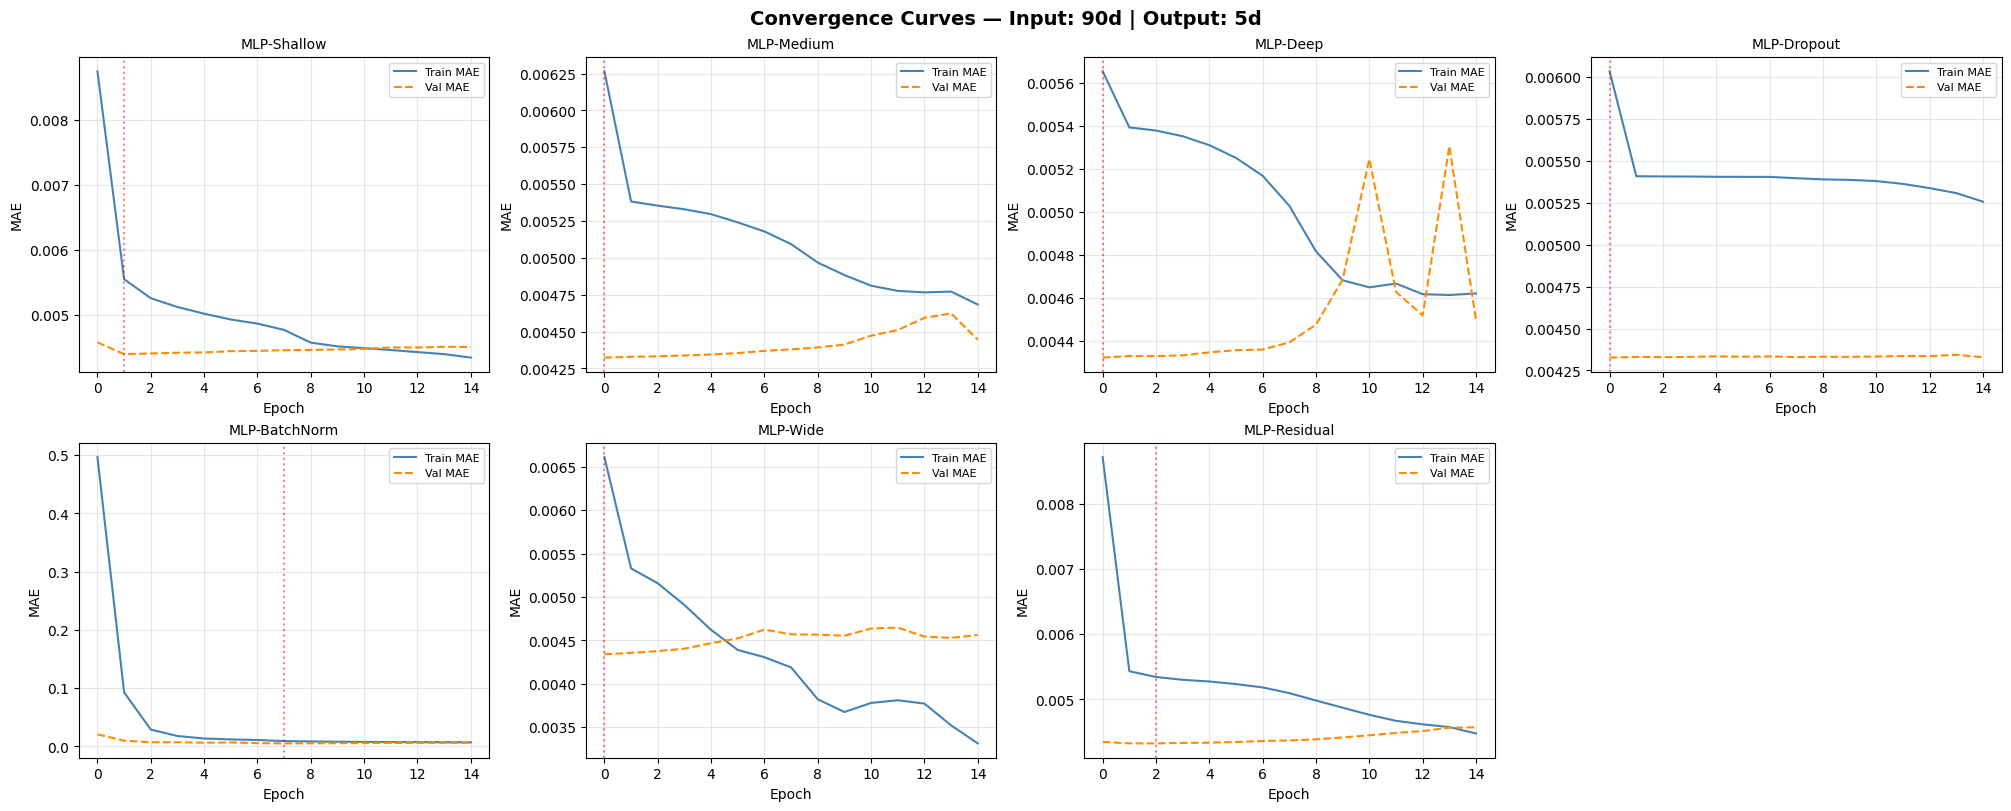

  → Saved: figuras/convergencia/conv_in90_out5.png


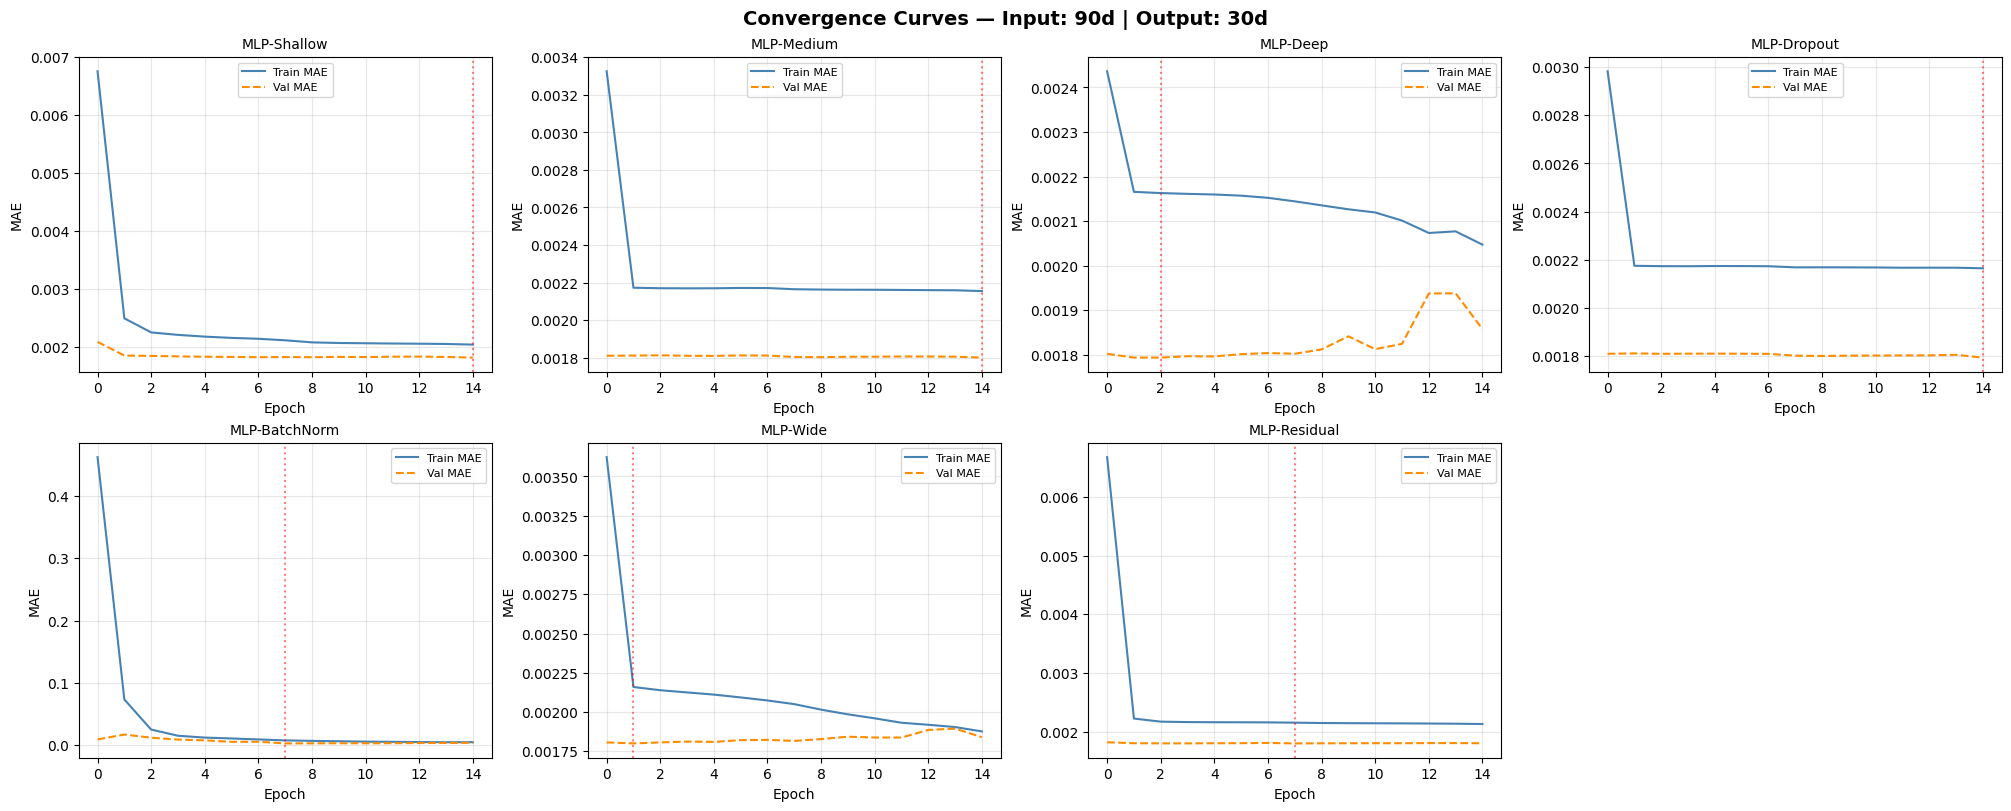

  → Saved: figuras/convergencia/conv_in90_out30.png


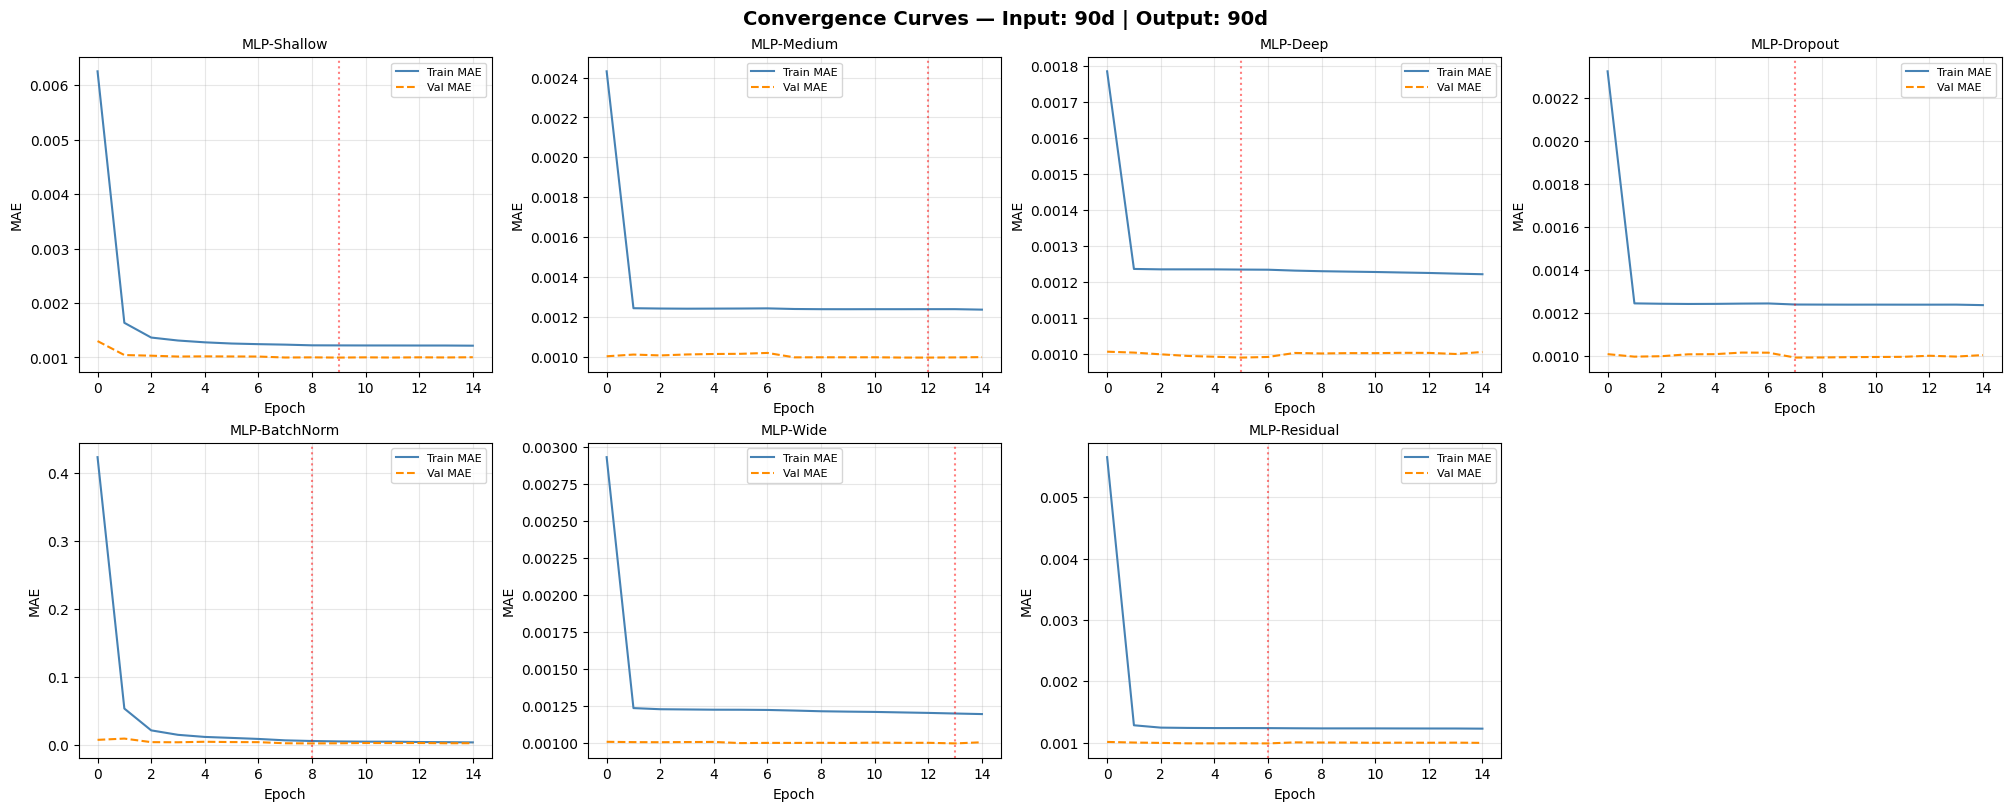

  → Saved: figuras/convergencia/conv_in90_out90.png


In [26]:
model_names = list(MODEL_BUILDERS.keys())  # 7 modelos

for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        fig, axes = plt.subplots(
            2, 4, figsize=(20, 8),
            constrained_layout=True
        )
        fig.suptitle(
            f'Convergence Curves — Input: {in_w}d | Output: {out_w}d',
            fontsize=14, fontweight='bold'
        )

        # Ocultar la 8ª gráfica (2x4 = 8 huecos, modelos = 7)
        axes[1, 3].set_visible(False)

        for ax, model_name in zip(axes.flat[:7], model_names):
            hist = histories.get((in_w, out_w, model_name), {})
            if hist:
                ax.plot(hist['loss'],     label='Train MAE', color='steelblue', linewidth=1.5)
                ax.plot(hist['val_loss'], label='Val MAE',   color='darkorange',
                        linewidth=1.5, linestyle='--')
                ax.set_title(model_name, fontsize=10)
                ax.set_xlabel('Epoch')
                ax.set_ylabel('MAE')
                ax.legend(fontsize=8)
                ax.grid(True, alpha=0.3)

                best_epoch = np.argmin(hist['val_loss'])
                ax.axvline(x=best_epoch, color='red', alpha=0.5, linestyle=':')

        fname = f'figuras/convergencia/conv_in{in_w}_out{out_w}.png'
        plt.savefig(fname, dpi=110, bbox_inches='tight')
        plt.show()
        print(f'  → Saved: {fname}')

## 8. Tablas de Resultados por Combinación

Para cada combinación de ventanas se muestra una tabla con MAE en train, val y test, el número de parámetros y las épocas entrenadas. **El mejor modelo en test queda remarcado en verde**.

In [29]:
results_df = pd.DataFrame(results_list)

# Mostrar tablas por combinación
for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        subset = results_df[
            (results_df['in_window'] == in_w) &
            (results_df['out_window'] == out_w)
        ].copy()

        # Ordenar por MAE test
        subset = subset.sort_values('mae_test')

        print(f'\n{"─"*75}')
        print(f'  Ventana entrada={in_w}d  |  Ventana salida={out_w}d')
        print(f'{"─"*75}')

        display_cols = ['model', 'params', 'mae_train', 'mae_val', 'mae_test', 'epochs_run']
        display_df = subset[display_cols].rename(columns={
            'model': 'Modelo',
            'params': '# Params',
            'mae_train': 'MAE Train',
            'mae_val': 'MAE Val',
            'mae_test': 'MAE Test',
            'epochs_run': 'Epochs'
        })

        # Formatear decimales
        for col in ['MAE Train', 'MAE Val', 'MAE Test']:
            display_df[col] = display_df[col].map('{:.6f}'.format)
        display_df['# Params'] = display_df['# Params'].map('{:,}'.format)

        # Highlight del mejor
        best_name = best_models.get((in_w, out_w), (None,))[0]

        def highlight_best(row):
            if row['Modelo'] == best_name:
                return ['font-weight: bold; text-decoration: underline'] * len(row)
            return [''] * len(row)

        styled = display_df.style.apply(highlight_best, axis=1)
        display(styled)

print('\n✓ Tablas generadas para las 16 combinaciones.')


───────────────────────────────────────────────────────────────────────────
  Ventana entrada=5d  |  Ventana salida=1d
───────────────────────────────────────────────────────────────────────────


,Modelo,# Params,MAE Train,MAE Val,MAE Test,Epochs
4,MLP-Dropout,"131,351",0.011686,0.009222,0.012284,15
2,MLP-Medium,"65,559",0.011604,0.009217,0.012314,19
6,MLP-Wide,"655,383",0.011636,0.009229,0.012315,15
3,MLP-Deep,"233,367",0.011515,0.009198,0.012347,24
7,MLP-Residual,"298,775",0.011719,0.009254,0.012363,15
1,MLP-Shallow,"17,815",0.011548,0.009233,0.012380,22
0,Buy & Hold,0,0.013060,0.010308,0.013628,0
5,MLP-BatchNorm,"133,911",0.030247,0.029297,0.030715,15



───────────────────────────────────────────────────────────────────────────
  Ventana entrada=5d  |  Ventana salida=5d
───────────────────────────────────────────────────────────────────────────


,Modelo,# Params,MAE Train,MAE Val,MAE Test,Epochs
11,MLP-Deep,"233,367",0.005393,0.004298,0.005591,17
12,MLP-Dropout,"131,351",0.005378,0.004293,0.005593,33
14,MLP-Wide,"655,383",0.005378,0.004306,0.005604,15
10,MLP-Medium,"65,559",0.005388,0.004304,0.005606,18
9,MLP-Shallow,"17,815",0.005257,0.004306,0.005676,34
15,MLP-Residual,"298,775",0.005437,0.004316,0.005676,15
8,Buy & Hold,0,0.007897,0.006236,0.008041,0
13,MLP-BatchNorm,"133,911",0.026351,0.025611,0.026590,15



───────────────────────────────────────────────────────────────────────────
  Ventana entrada=5d  |  Ventana salida=30d
───────────────────────────────────────────────────────────────────────────


...


───────────────────────────────────────────────────────────────────────────
  Ventana entrada=90d  |  Ventana salida=30d
───────────────────────────────────────────────────────────────────────────


,Modelo,# Params,MAE Train,MAE Val,MAE Test,Epochs
115,MLP-Deep,"1,234,327",0.002166,0.001802,0.002330,15
116,MLP-Dropout,"631,831",0.002170,0.001810,0.002335,15
118,MLP-Wide,"2,657,303",0.002160,0.001807,0.002344,15
114,MLP-Medium,"566,039",0.002170,0.001810,0.002360,15
119,MLP-Residual,"799,255",0.002297,0.001820,0.002696,15
112,Buy & Hold,0,0.002507,0.002089,0.002756,0
113,MLP-Shallow,"268,055",0.002724,0.002083,0.003411,15
117,MLP-BatchNorm,"634,391",0.009821,0.008930,0.010386,15



───────────────────────────────────────────────────────────────────────────
  Ventana entrada=90d  |  Ventana salida=90d
───────────────────────────────────────────────────────────────────────────


,Modelo,# Params,MAE Train,MAE Val,MAE Test,Epochs
124,MLP-Dropout,"631,831",0.001238,0.001007,0.001271,15
123,MLP-Deep,"1,234,327",0.001237,0.001006,0.001276,15
122,MLP-Medium,"566,039",0.001243,0.001001,0.001291,15
126,MLP-Wide,"2,657,303",0.001239,0.001009,0.001295,15
127,MLP-Residual,"799,255",0.001339,0.001012,0.001550,15
120,Buy & Hold,0,0.001752,0.001373,0.001824,0
121,MLP-Shallow,"268,055",0.001904,0.001300,0.002420,15
125,MLP-BatchNorm,"634,391",0.007922,0.007528,0.008281,15



✓ Tablas generadas para las 16 combinaciones.


## 9. Gráficas Comparativas por Combinación

16 gráficas (una por combinación) con el MAE en test de cada modelo, más el baseline.

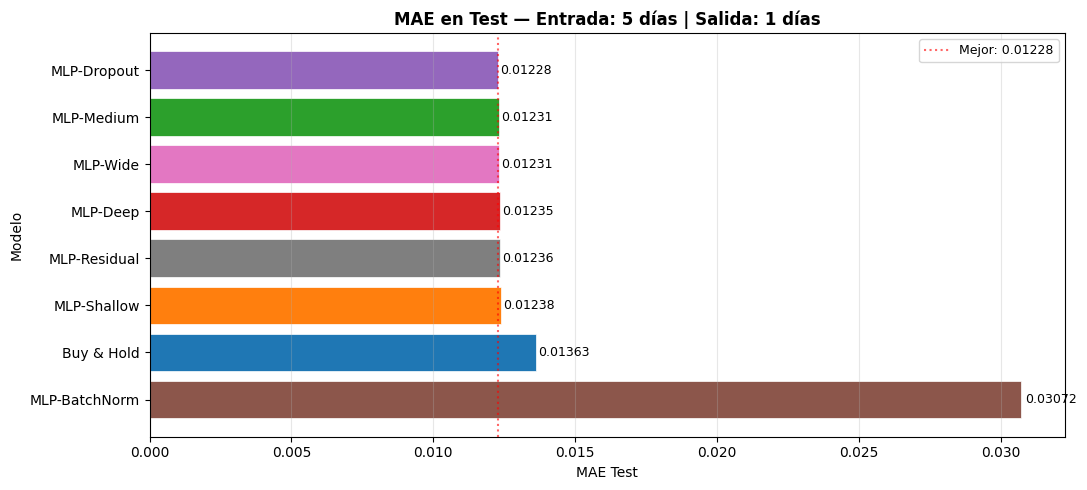

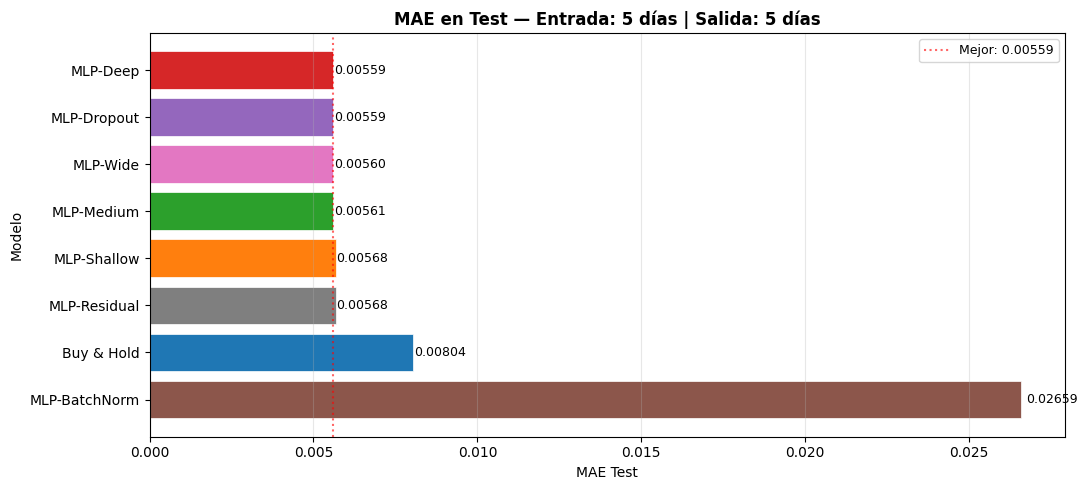

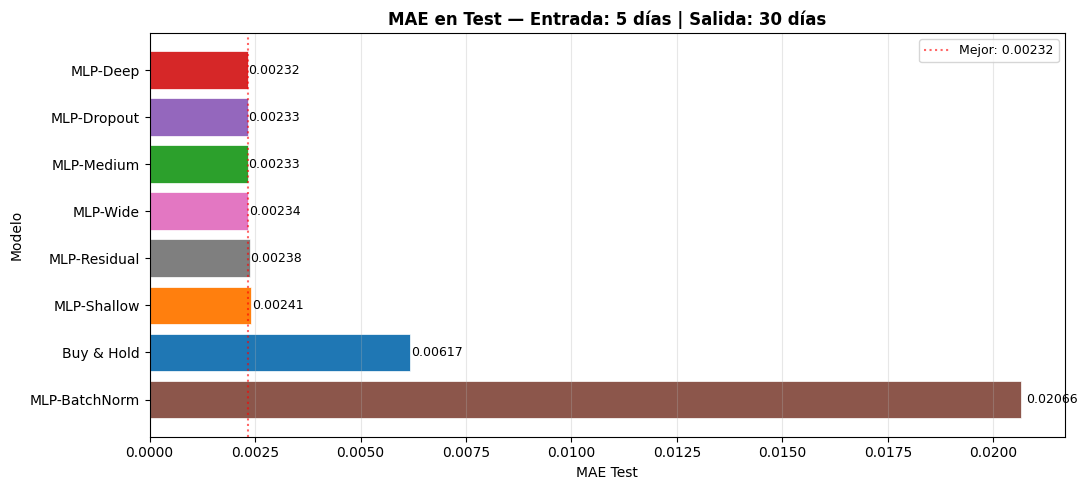

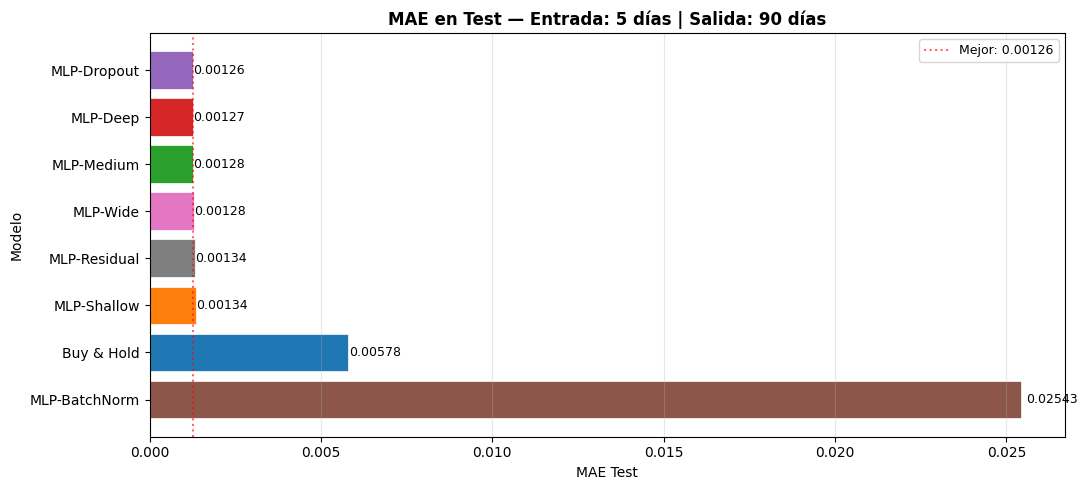

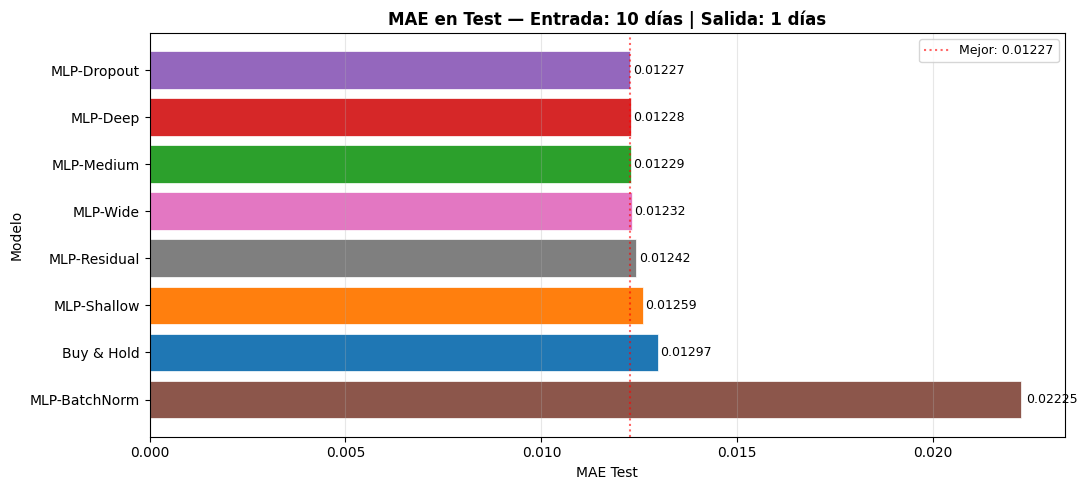

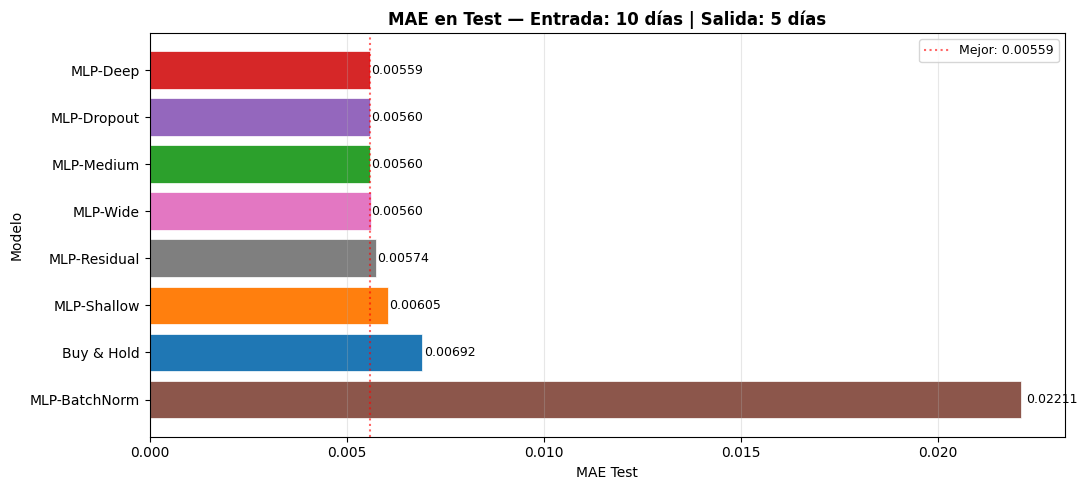

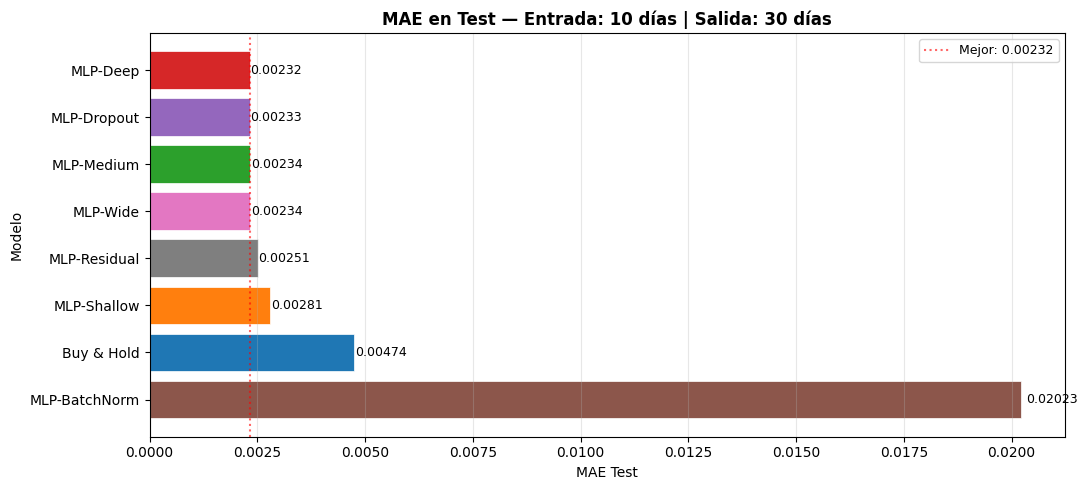

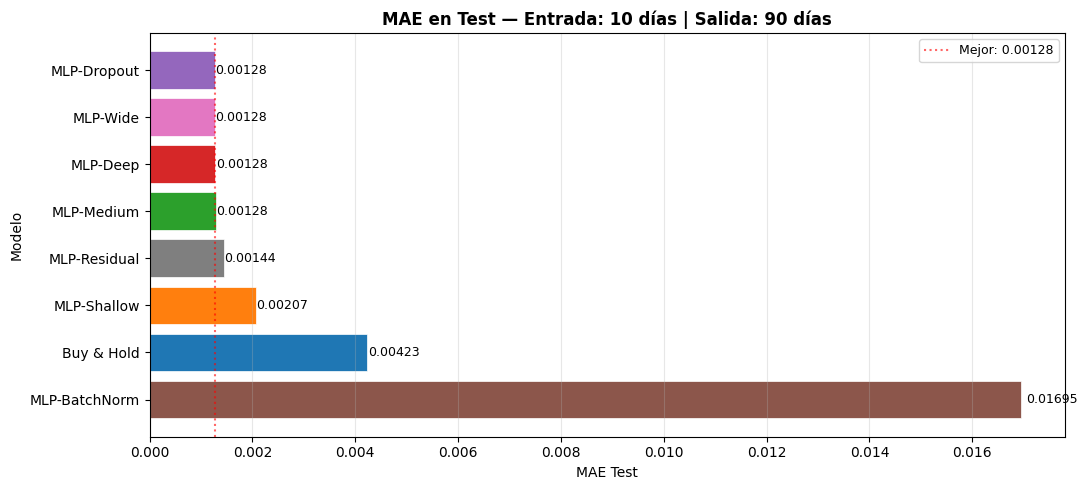

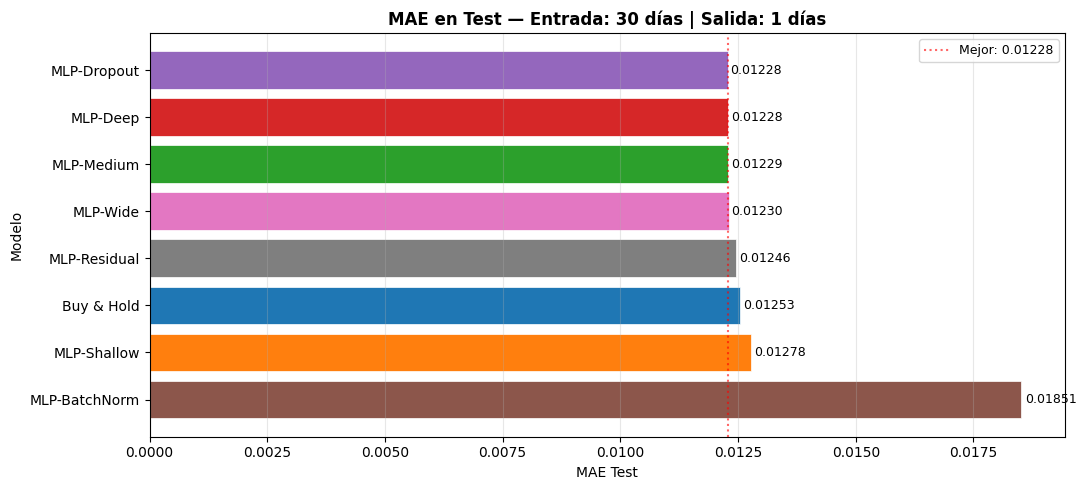

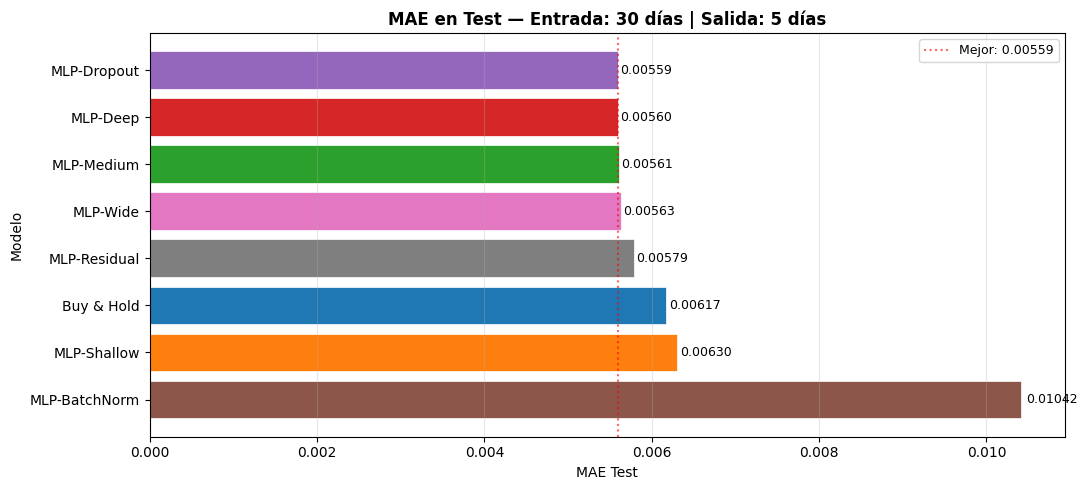

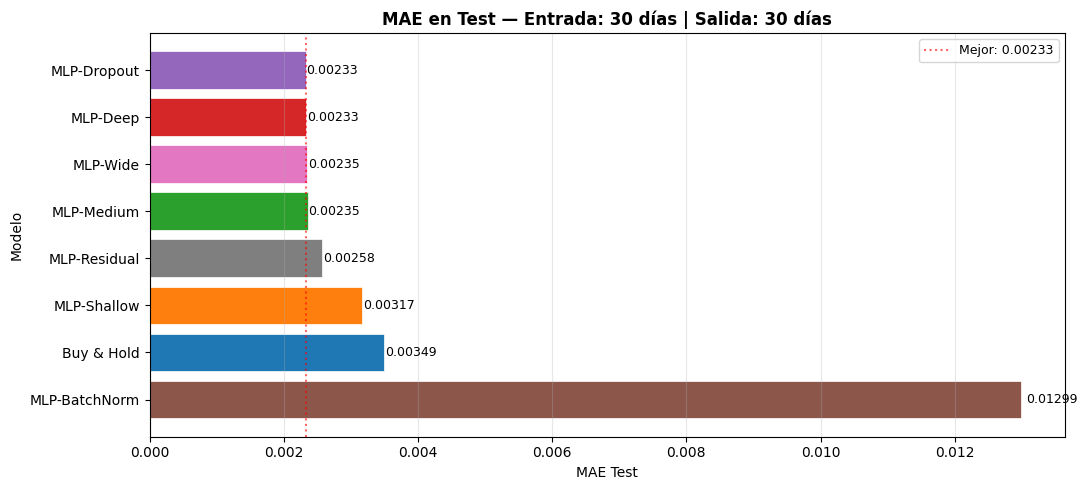

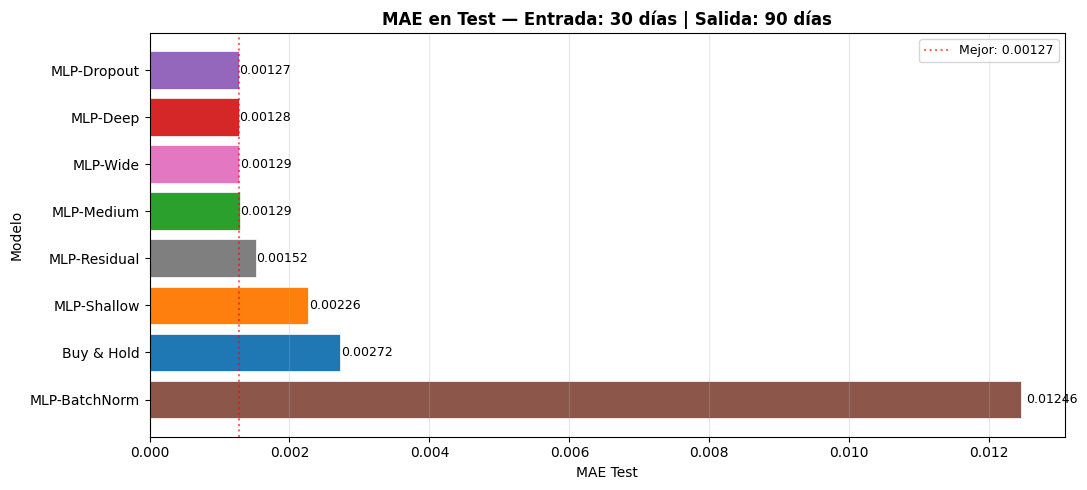

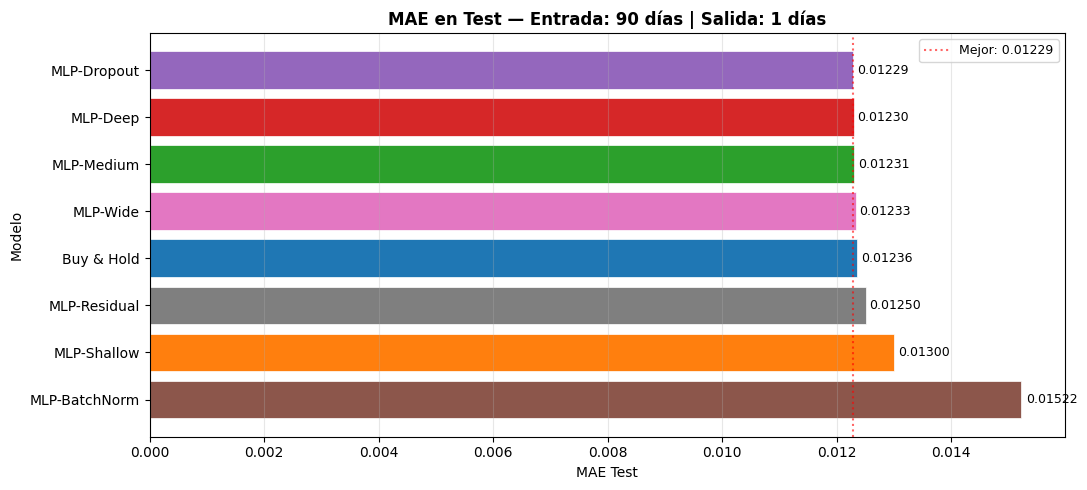

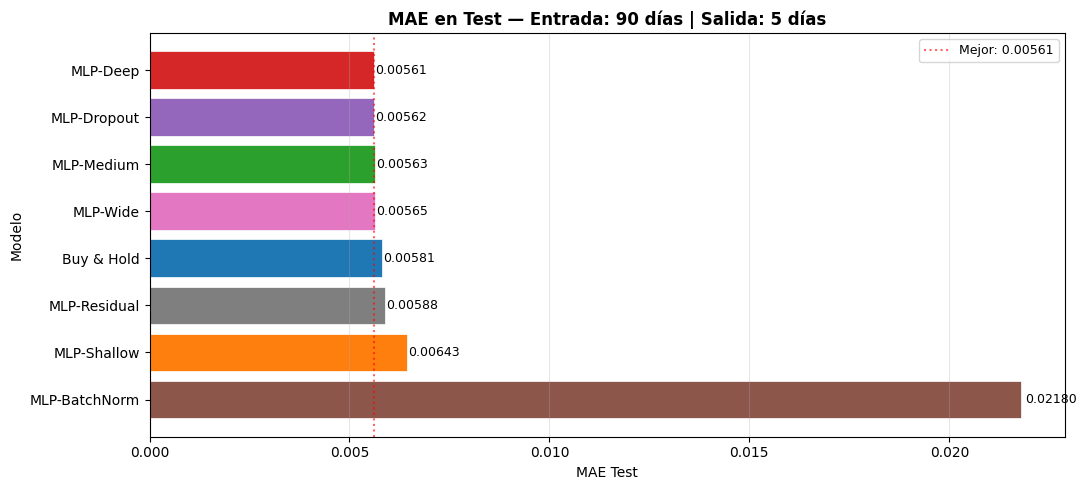

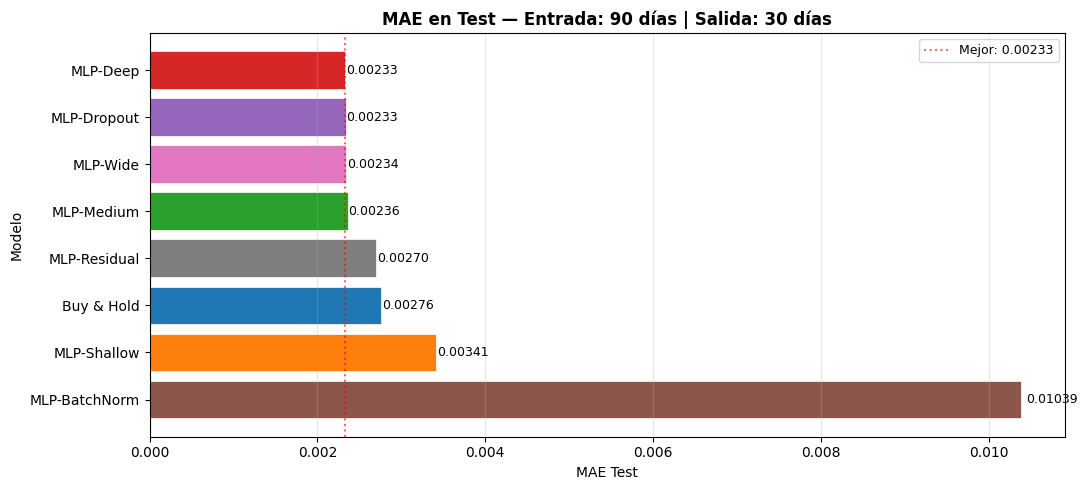

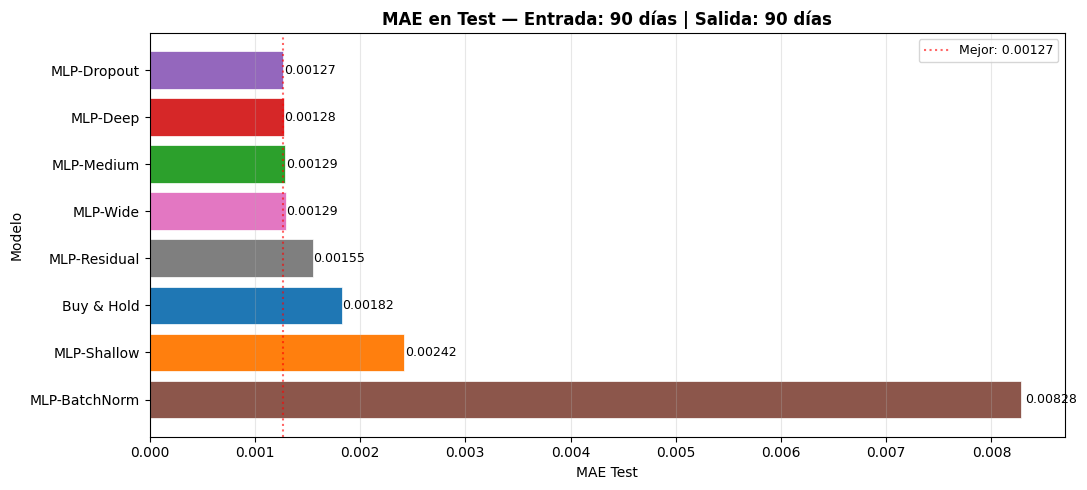

✓ 16 gráficas de comparación generadas.


In [18]:
# ── Paleta de colores ─────────────────────────────────────────────
MODEL_ORDER = ['Buy & Hold'] + list(MODEL_BUILDERS.keys())
palette = plt.cm.tab10.colors
color_map = {m: palette[i % len(palette)] for i, m in enumerate(MODEL_ORDER)}

# ── 16 gráficas individuales ──────────────────────────────────────
for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        subset = results_df[
            (results_df['in_window'] == in_w) &
            (results_df['out_window'] == out_w)
        ].sort_values('mae_test')

        fig, ax = plt.subplots(figsize=(11, 5))

        bars = ax.barh(
            subset['model'],
            subset['mae_test'],
            color=[color_map.get(m, 'gray') for m in subset['model']],
            edgecolor='white', linewidth=0.5
        )

        # Añadir valor numérico
        for bar, val in zip(bars, subset['mae_test']):
            ax.text(
                bar.get_width() + bar.get_width() * 0.005,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.5f}', va='center', ha='left', fontsize=9
            )

        # Marcar el mejor
        best_val = subset['mae_test'].min()
        ax.axvline(best_val, color='red', linestyle=':', alpha=0.6, label=f'Mejor: {best_val:.5f}')

        ax.set_title(
            f'MAE en Test — Entrada: {in_w} días | Salida: {out_w} días',
            fontsize=12, fontweight='bold'
        )
        ax.set_xlabel('MAE Test')
        ax.set_ylabel('Modelo')
        ax.legend(fontsize=9)
        ax.grid(True, axis='x', alpha=0.3)
        ax.invert_yaxis()

        plt.tight_layout()
        fname = f'figuras/comparacion_in{in_w}_out{out_w}.png'
        plt.savefig(fname, dpi=120, bbox_inches='tight')
        plt.show()

print('✓ 16 gráficas de comparación generadas.')

## 10. Gráficas Resumen por Ventana de Salida

Una gráfica que agrupa todos los resultados para cada ventana de salida (4 gráficas), mostrando el MAE test de todos los modelos en las 4 ventanas de entrada.

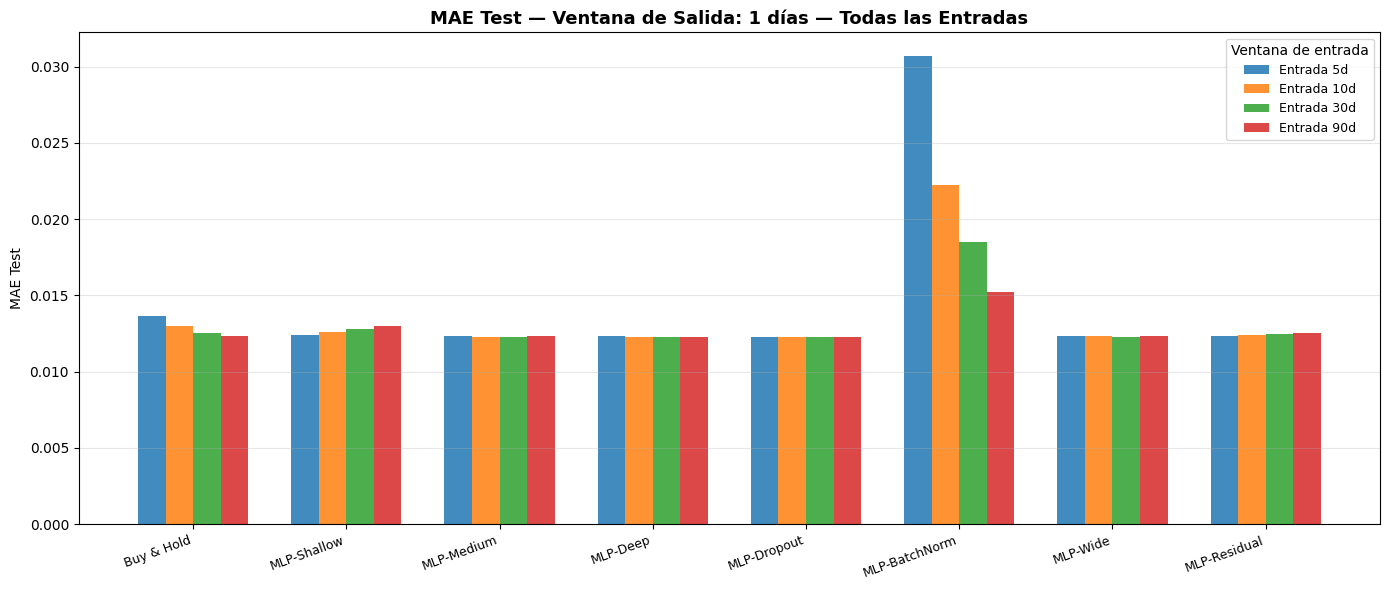

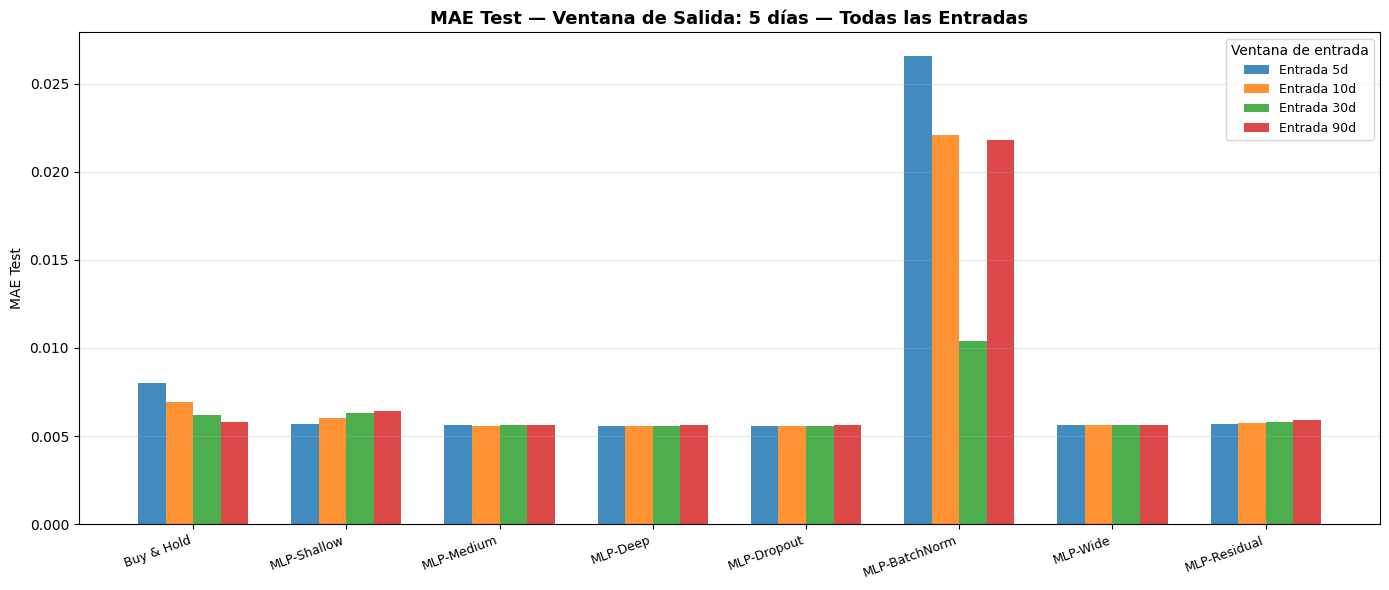

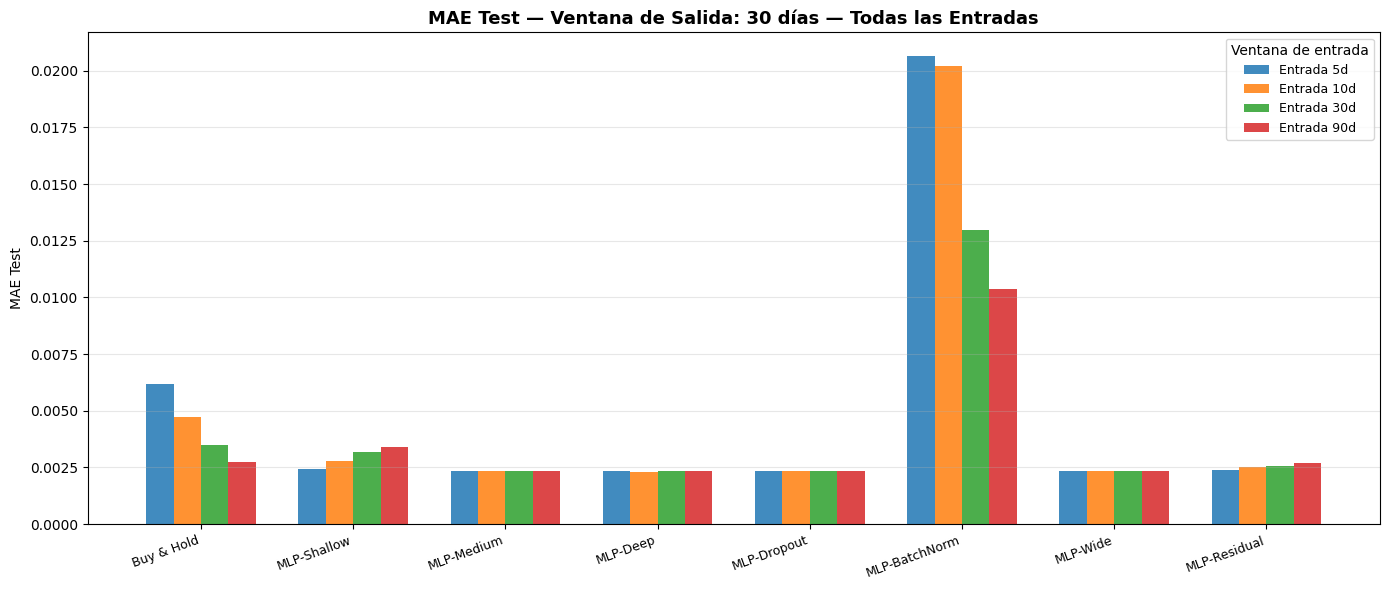

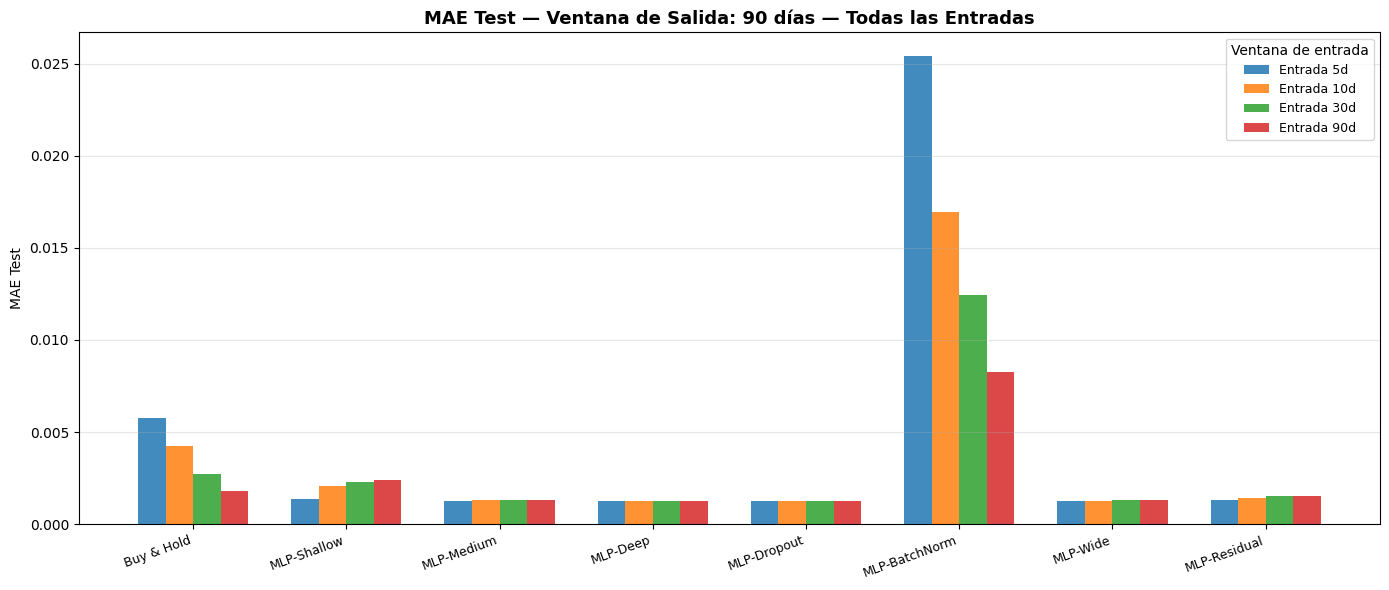

✓ 4 gráficas resumen por ventana de salida generadas.


In [19]:
for out_w in OUTPUT_WINDOWS:
    subset_out = results_df[results_df['out_window'] == out_w]

    fig, ax = plt.subplots(figsize=(14, 6))

    x = np.arange(len(MODEL_ORDER))
    width = 0.18
    offsets = np.linspace(-1.5, 1.5, len(INPUT_WINDOWS)) * width

    for i, in_w in enumerate(INPUT_WINDOWS):
        row = subset_out[subset_out['in_window'] == in_w]
        mae_vals = [
            row[row['model'] == m]['mae_test'].values[0]
            if len(row[row['model'] == m]) > 0 else np.nan
            for m in MODEL_ORDER
        ]
        ax.bar(
            x + offsets[i], mae_vals, width,
            label=f'Entrada {in_w}d',
            alpha=0.85
        )

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('MAE Test')
    ax.set_title(
        f'MAE Test — Ventana de Salida: {out_w} días — Todas las Entradas',
        fontsize=13, fontweight='bold'
    )
    ax.legend(title='Ventana de entrada', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    fname = f'figuras/resumen_salida{out_w}.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()

print('✓ 4 gráficas resumen por ventana de salida generadas.')

## 11. Matriz de Competición

Matriz **4×4** (ventanas entrada × ventanas salida) con el **MAE test del mejor modelo** para cada combinación. Este es el resultado de competición a reportar.

In [20]:
# ── Construir la matriz de competición ────────────────────────────
competition_matrix = pd.DataFrame(
    index=[f'Entrada {in_w}d' for in_w in INPUT_WINDOWS],
    columns=[f'Salida {out_w}d' for out_w in OUTPUT_WINDOWS],
    dtype=float
)
best_model_matrix = pd.DataFrame(
    index=[f'Entrada {in_w}d' for in_w in INPUT_WINDOWS],
    columns=[f'Salida {out_w}d' for out_w in OUTPUT_WINDOWS],
    dtype=str
)

for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        subset = results_df[
            (results_df['in_window'] == in_w) &
            (results_df['out_window'] == out_w)
        ]
        best_row = subset.loc[subset['mae_test'].idxmin()]
        competition_matrix.loc[f'Entrada {in_w}d', f'Salida {out_w}d'] = best_row['mae_test']
        best_model_matrix.loc[f'Entrada {in_w}d', f'Salida {out_w}d']  = best_row['model']

print('MATRIZ DE COMPETICIÓN — MAE Test (mejor modelo por combinación)')
print('='*65)
print(competition_matrix.to_string(float_format='{:.6f}'.format))

print('\nMODELO GANADOR POR COMBINACIÓN')
print('='*65)
print(best_model_matrix.to_string())

MATRIZ DE COMPETICIÓN — MAE Test (mejor modelo por combinación)
             Salida 1d  Salida 5d  Salida 30d  Salida 90d
Entrada 5d    0.012284   0.005591    0.002324    0.001262
Entrada 10d   0.012273   0.005591    0.002322    0.001276
Entrada 30d   0.012278   0.005594    0.002326    0.001274
Entrada 90d   0.012287   0.005613    0.002330    0.001271

MODELO GANADOR POR COMBINACIÓN
               Salida 1d    Salida 5d   Salida 30d   Salida 90d
Entrada 5d   MLP-Dropout     MLP-Deep     MLP-Deep  MLP-Dropout
Entrada 10d  MLP-Dropout     MLP-Deep     MLP-Deep  MLP-Dropout
Entrada 30d  MLP-Dropout  MLP-Dropout  MLP-Dropout  MLP-Dropout
Entrada 90d  MLP-Dropout     MLP-Deep     MLP-Deep  MLP-Dropout


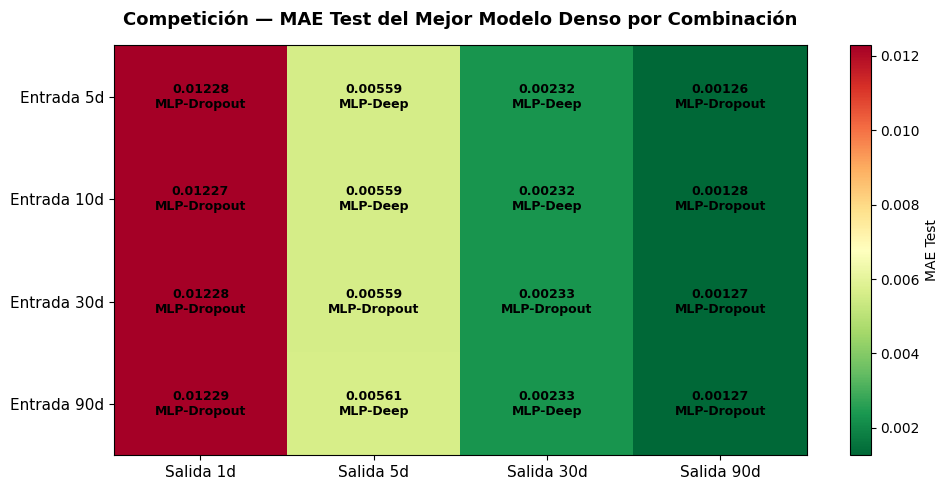

✓ Matriz de competición guardada.


In [21]:
# ── Visualización de la matriz como heatmap ────────────────────────
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 5))

mat_vals = competition_matrix.values.astype(float)
im = ax.imshow(mat_vals, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(OUTPUT_WINDOWS)))
ax.set_yticks(range(len(INPUT_WINDOWS)))
ax.set_xticklabels([f'Salida {w}d' for w in OUTPUT_WINDOWS], fontsize=11)
ax.set_yticklabels([f'Entrada {w}d' for w in INPUT_WINDOWS], fontsize=11)
ax.set_title(
    'Competición — MAE Test del Mejor Modelo Denso por Combinación',
    fontsize=13, fontweight='bold', pad=15
)

# Anotaciones en cada celda
for i in range(len(INPUT_WINDOWS)):
    for j in range(len(OUTPUT_WINDOWS)):
        val  = mat_vals[i, j]
        name = best_model_matrix.iloc[i, j]
        ax.text(
            j, i,
            f'{val:.5f}\n{name}',
            ha='center', va='center',
            fontsize=9, fontweight='bold',
            color='black'
        )

plt.colorbar(im, ax=ax, label='MAE Test')
plt.tight_layout()
plt.savefig('figuras/matriz_competicion.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Matriz de competición guardada.')

## 12. Análisis: ¿Qué modelos funcionan mejor?

Resumen estadístico de rendimiento de cada arquitectura densa a través de todas las combinaciones.

RANKING GLOBAL DE MODELOS (MAE Test promedio sobre 16 combinaciones)
               MAE medio      Std  MAE mín  MAE máx
model                                              
MLP-Dropout     0.005370 0.004438 0.001262 0.012287
MLP-Deep        0.005376 0.004445 0.001272 0.012347
MLP-Medium      0.005386 0.004439 0.001280 0.012314
MLP-Wide        0.005391 0.004446 0.001277 0.012328
MLP-Residual    0.005553 0.004420 0.001336 0.012503
MLP-Shallow     0.005944 0.004330 0.001345 0.013005
Buy & Hold      0.006884 0.003935 0.001824 0.013628
MLP-BatchNorm   0.018438 0.006449 0.008281 0.030715


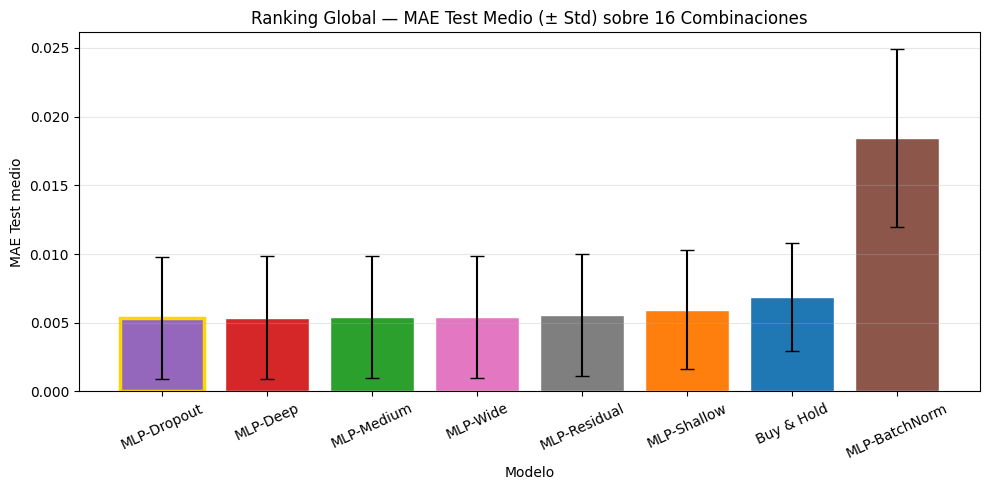


★ Mejor arquitectura global: MLP-Dropout


In [22]:
# Ranking global de modelos (media del MAE test sobre las 16 combinaciones)
global_ranking = (
    results_df
    .groupby('model')['mae_test']
    .agg(['mean', 'std', 'min', 'max'])
    .sort_values('mean')
    .rename(columns={'mean': 'MAE medio', 'std': 'Std', 'min': 'MAE mín', 'max': 'MAE máx'})
)

print('RANKING GLOBAL DE MODELOS (MAE Test promedio sobre 16 combinaciones)')
print('='*70)
print(global_ranking.to_string(float_format='{:.6f}'.format))

# Figura del ranking
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    global_ranking.index,
    global_ranking['MAE medio'],
    yerr=global_ranking['Std'],
    capsize=5,
    color=[color_map.get(m, 'gray') for m in global_ranking.index],
    edgecolor='white'
)
ax.set_title('Ranking Global — MAE Test Medio (± Std) sobre 16 Combinaciones', fontsize=12)
ax.set_ylabel('MAE Test medio')
ax.set_xlabel('Modelo')
ax.tick_params(axis='x', rotation=25)
ax.grid(True, axis='y', alpha=0.3)

# Marcar el mejor
best_global = global_ranking.index[0]
for bar, name in zip(bars, global_ranking.index):
    if name == best_global:
        bar.set_edgecolor('gold')
        bar.set_linewidth(2.5)

plt.tight_layout()
plt.savefig('figuras/ranking_global.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n★ Mejor arquitectura global: {best_global}')

Victorias por modelo (mejor MAE Test en cada combinación):
MLP-Dropout      10
MLP-Deep          6
MLP-Shallow       0
Buy & Hold        0
MLP-Medium        0
MLP-BatchNorm     0
MLP-Wide          0
MLP-Residual      0


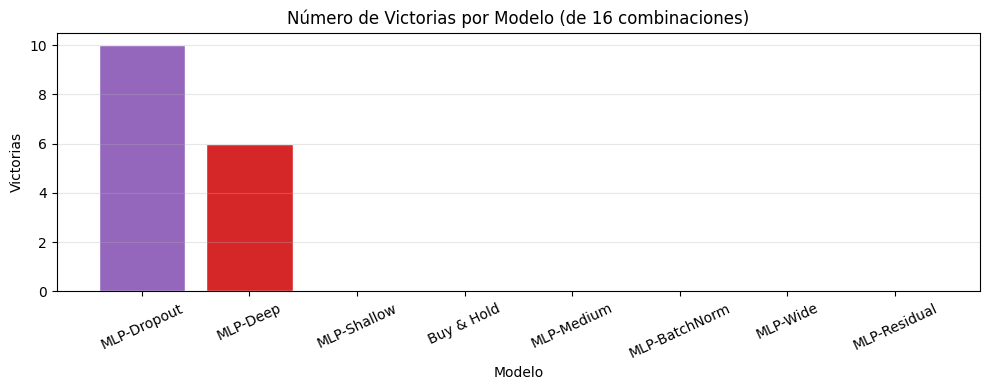

In [23]:
# ── Conteo de victorias por modelo (veces que es el mejor en test) ─
wins = {m: 0 for m in MODEL_ORDER}
for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        winner = best_models.get((in_w, out_w), (None,))[0]
        if winner and winner in wins:
            wins[winner] += 1

wins_df = pd.Series(wins).sort_values(ascending=False)
print('Victorias por modelo (mejor MAE Test en cada combinación):')
print(wins_df.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    wins_df.index, wins_df.values,
    color=[color_map.get(m, 'gray') for m in wins_df.index],
    edgecolor='white'
)
ax.set_title('Número de Victorias por Modelo (de 16 combinaciones)', fontsize=12)
ax.set_ylabel('Victorias')
ax.set_xlabel('Modelo')
ax.tick_params(axis='x', rotation=25)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figuras/victorias_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

## 13. Exportar Resultados Completos a CSV

In [30]:
results_df.to_csv('resultados_dense_models.csv', index=False)
competition_matrix.to_csv('matriz_competicion_dense.csv')

print('Archivos guardados:')
print('  · resultados_dense_models.csv    — todos los resultados')
print('  · matriz_competicion_dense.csv  — matriz de competición')
print()
print(f'Total de modelos entrenados: {len(results_df)}')
print(f'Combinaciones de ventanas:   {len(INPUT_WINDOWS) * len(OUTPUT_WINDOWS)}')
print(f'Arquitecturas por combo:     {len(MODEL_BUILDERS) + 1} (incluyendo Buy & Hold)')

Archivos guardados:
  · resultados_dense_models.csv    — todos los resultados
  · matriz_competicion_dense.csv  — matriz de competición

Total de modelos entrenados: 128
Combinaciones de ventanas:   16
Arquitecturas por combo:     8 (incluyendo Buy & Hold)
